<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 14px;
    padding: 30px 34px;
    margin: 10px 0 24px 0;
    box-shadow: 0 4px 16px rgba(0,0,0,0.20);
">
    <h1 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 34px;
        font-weight: bold;
        text-align: center;
    ">
        Analyse du stock et des ventes du site BottleNeck
    </h1>
    <p style="
        margin: 14px 0 0 0;
        color: #EAF9FC;
        font-family: Arial, sans-serif;
        font-size: 16px;
        text-align: center;
    ">
        Nettoyage, consolidation et analyse des données ERP, Web et Liaison
    </p>
</div>

<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 18px 22px;
    margin: 14px 0 24px 0;
    border-radius: 8px;
">
    <h2 style="margin:0; color:#1E7D8B; font-family:Arial, sans-serif;">Objectif du notebook</h2>
    <p style="color:#34495E; font-family:Arial, sans-serif; font-size:15px; line-height:1.6;">
        Ce notebook présente le travail de préparation, de contrôle, de nettoyage et d’analyse des données de BottleNeck.
        L’objectif est de rapprocher les données issues de l’ERP, du site Web WordPress et de la table de liaison afin d’obtenir
        une base consolidée exploitable pour analyser le chiffre d’affaires, les ventes, les stocks, les marges, les valeurs aberrantes
        et les corrélations entre variables quantitatives.
    </p>
</div>

### Contexte de la mission

BottleNeck dispose de plusieurs exports de données :

- une extraction de l’ERP avec les références produits, les prix, les stocks et les prix d’achat ;
- une extraction du site Web WordPress avec les SKU, les ventes, les titres et les informations produits ;
- une table de liaison permettant de rapprocher les références entre les deux systèmes.

Le travail est organisé en deux grandes phases :

1. **Préparer et fiabiliser les données** : explorer, contrôler, nettoyer et consolider les fichiers.
2. **Analyser les données pour le CODIR** : chiffre d’affaires, ventes, stocks, marges, valeurs aberrantes, 20/80 et corrélations.

<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 1 — Importation des librairies et chargement des fichiers
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : préparer l’environnement de travail et charger les trois fichiers sources du projet BottleNeck.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        1.1 — Importation des librairies
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Chargement des bibliothèques nécessaires à la manipulation, l’exploration et la visualisation des données.</p>
</div>

In [1]:
# Librairies principales
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# Plotly peut être utilisé en option, mais les graphiques du notebook sont en Matplotlib pour une meilleure compatibilité PyCharm.
# import plotly.express as px

# Gestion des chemins et des avertissements
from pathlib import Path
import warnings

# Affichage enrichi dans le notebook
from IPython.display import display, HTML, Markdown

# Masquer les avertissements non bloquants liés à certains éléments internes des fichiers Excel
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Options d'affichage Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Paramètres graphiques
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        1.1.1 — Thème visuel et fonctions d’affichage
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">
        Harmonisation des tableaux, indicateurs et messages pour rendre le notebook plus lisible et plus professionnel.
    </p>
</div>

In [2]:
# Thème visuel du notebook et fonctions d'affichage

THEME = {
    "primary": "#33A5B6",
    "primary_dark": "#1E7D8B",
    "primary_soft": "#F4FAFB",
    "text": "#34495E",
    "warning": "#F2B134",
    "danger": "#C0392B",
    "success": "#2E7D32"
}

# CSS global : améliore les tableaux dans le notebook.
# Les grands tableaux ne sont plus comprimés : ils gardent leur largeur naturelle avec un scroll horizontal.
display(HTML(f"""
<style>
    .bn-table-wrapper {{
        margin: 12px 0 18px 0;
        max-width: 100%;
        overflow-x: auto;
        overflow-y: auto;
        border-radius: 10px;
        box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        border: 1px solid #D9EEF2;
        background: white;
    }}
    .bn-table-wrapper.bn-wide {{
        max-height: 520px;
    }}
    table.bn-table {{
        border-collapse: collapse !important;
        width: max-content !important;
        min-width: 100% !important;
        table-layout: auto !important;
        font-family: Arial, sans-serif !important;
        font-size: 13px !important;
        color: #263238 !important;
        background-color: white !important;
    }}
    table.bn-table thead th {{
        background-color: {THEME['primary_dark']} !important;
        color: white !important;
        font-weight: 700 !important;
        text-align: left !important;
        padding: 10px 12px !important;
        border: 1px solid #D9EEF2 !important;
        white-space: nowrap !important;
        position: sticky;
        top: 0;
        z-index: 2;
    }}
    table.bn-table tbody td,
    table.bn-table tbody th {{
        padding: 8px 12px !important;
        border: 1px solid #E5EEF0 !important;
        vertical-align: top !important;
        white-space: nowrap !important;
        max-width: 420px;
        overflow: hidden;
        text-overflow: ellipsis;
    }}
    table.bn-table tbody tr:nth-child(even) {{
        background-color: #F8FBFC !important;
    }}
    table.bn-table tbody tr:hover {{
        background-color: #EAF9FC !important;
    }}
    .bn-browser-link {{
        display: inline-block;
        margin: 6px 0 12px 0;
        padding: 8px 12px;
        background: {THEME['primary_soft']};
        border-left: 5px solid {THEME['primary']};
        border-radius: 6px;
        font-family: Arial, sans-serif;
        color: {THEME['primary_dark']} !important;
        font-weight: bold;
        text-decoration: none !important;
    }}
</style>
"""))


def _formatter_colonne(nom_colonne: str, serie: pd.Series):
    """Détermine un format d'affichage adapté au nom et au contenu d'une colonne."""
    col = str(nom_colonne).lower()

    if not pd.api.types.is_numeric_dtype(serie):
        return None

    # Identifiants : éviter les décimales et les symboles monétaires
    if any(mot in col for mot in ["id", "sku", "key"]):
        return lambda x: "" if pd.isna(x) else f"{x:,.0f}".replace(",", " ")

    # Colonnes déjà exprimées en pourcentage 0-100
    if "%" in col:
        return lambda x: "" if pd.isna(x) else f"{x:,.2f} %".replace(",", " ").replace(".", ",")

    # Ratios / taux / parts en général stockés entre 0 et 1
    if any(mot in col for mot in ["taux", "part", "corr", "ratio"]):
        return lambda x: "" if pd.isna(x) else f"{x:.2%}".replace(".", ",")

    # Montants monétaires
    if any(mot in col for mot in ["prix", "price", "ca", "chiffre", "valorisation", "marge", "purchase", "achat"]):
        return lambda x: "" if pd.isna(x) else f"{x:,.2f} €".replace(",", " ").replace(".", ",")

    # Volumes, comptes, stocks, ventes
    if any(mot in col for mot in ["nombre", "lignes", "colonnes", "valeurs", "stock", "sales", "quantite", "quantité", "ventes"]):
        return lambda x: "" if pd.isna(x) else f"{x:,.0f}".replace(",", " ")

    return lambda x: "" if pd.isna(x) else f"{x:,.2f}".replace(",", " ").replace(".", ",")


def _slugifier(texte: str) -> str:
    """Convertit un titre en nom de fichier simple."""
    import re
    texte = str(texte).strip().lower()
    texte = re.sub(r"[^a-z0-9A-ZÀ-ÿ]+", "_", texte)
    texte = texte.strip("_")
    return texte[:80] or "tableau"


def _preparer_html_tableau(df: pd.DataFrame, masquer_index: bool | None = None) -> str:
    """Prépare le HTML d'un DataFrame avec formatage des colonnes."""
    if masquer_index is None:
        masquer_index = isinstance(df.index, pd.RangeIndex)

    formatters = {
        col: fmt for col in df.columns
        if (fmt := _formatter_colonne(str(col), df[col])) is not None
    }

    return df.to_html(
        classes="bn-table",
        index=not masquer_index,
        border=0,
        escape=True,
        formatters=formatters,
        na_rep=""
    )


def exporter_tableau_html(obj, titre: str = "Tableau", nom_fichier: str | None = None, max_lignes: int | None = None) -> Path | None:
    """Exporte un tableau dans un fichier HTML local lisible dans le navigateur."""
    if isinstance(obj, pd.Series):
        obj = obj.reset_index()

    if not isinstance(obj, pd.DataFrame):
        return None

    df = obj.copy()
    if max_lignes is not None:
        df = df.head(max_lignes)

    dossier_export = Path("exports") / "tableaux"
    dossier_export.mkdir(parents=True, exist_ok=True)

    nom = _slugifier(nom_fichier or titre)
    chemin = dossier_export / f"{nom}.html"
    table_html = _preparer_html_tableau(df)

    page_html = f"""
<!doctype html>
<html lang="fr">
<head>
<meta charset="utf-8">
<title>{titre}</title>
<style>
    body {{
        font-family: Arial, sans-serif;
        margin: 24px;
        background: #F4FAFB;
        color: #263238;
    }}
    h1 {{
        color: #1E7D8B;
        margin-bottom: 6px;
    }}
    .meta {{
        color: #607D8B;
        margin-bottom: 18px;
    }}
    .toolbar {{
        position: sticky;
        top: 0;
        z-index: 5;
        background: #F4FAFB;
        padding: 10px 0 14px 0;
    }}
    input {{
        width: min(680px, 96%);
        padding: 11px 13px;
        border: 1px solid #B7DDE4;
        border-radius: 8px;
        font-size: 15px;
        outline: none;
    }}
    input:focus {{
        border-color: #33A5B6;
        box-shadow: 0 0 0 3px rgba(51,165,182,0.15);
    }}
    .table-wrap {{
        border: 1px solid #D9EEF2;
        background: white;
        border-radius: 10px;
        overflow: auto;
        max-height: 78vh;
        box-shadow: 0 3px 14px rgba(0,0,0,0.10);
    }}
    table.bn-table {{
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        font-size: 13px;
    }}
    table.bn-table thead th {{
        position: sticky;
        top: 0;
        z-index: 3;
        background: #1E7D8B;
        color: white;
        text-align: left;
        padding: 10px 12px;
        border: 1px solid #D9EEF2;
        white-space: nowrap;
    }}
    table.bn-table tbody td,
    table.bn-table tbody th {{
        padding: 8px 12px;
        border: 1px solid #E5EEF0;
        vertical-align: top;
        white-space: nowrap;
    }}
    table.bn-table tbody tr:nth-child(even) {{ background: #F8FBFC; }}
    table.bn-table tbody tr:hover {{ background: #EAF9FC; }}
</style>
</head>
<body>
    <h1>{titre}</h1>
    <div class="meta">{df.shape[0]} ligne(s) affichée(s) · {df.shape[1]} colonne(s)</div>
    <div class="toolbar">
        <input id="searchInput" type="text" placeholder="Rechercher dans le tableau..." onkeyup="filterTable()">
    </div>
    <div class="table-wrap">
        {table_html}
    </div>
<script>
function filterTable() {{
    const input = document.getElementById('searchInput');
    const filter = input.value.toLowerCase();
    const table = document.querySelector('table.bn-table');
    const rows = table.querySelectorAll('tbody tr');
    rows.forEach(row => {{
        const text = row.textContent.toLowerCase();
        row.style.display = text.includes(filter) ? '' : 'none';
    }});
}}
</script>
</body>
</html>
"""

    chemin.write_text(page_html, encoding="utf-8")
    return chemin


def afficher_tableau(obj, titre: str | None = None, max_lignes: int | None = None, masquer_index: bool | None = None,
                     ouvrir_navigateur: bool = False, nom_fichier: str | None = None):
    """Affiche un tableau lisible dans le notebook et propose une version navigateur pour les grands tableaux.

    Paramètres utiles :
    - titre="..." : ajoute un titre au tableau ;
    - max_lignes=20 : limite l'affichage ;
    - ouvrir_navigateur=True : ouvre automatiquement une page HTML locale dans le navigateur ;
    - nom_fichier="..." : nom du fichier HTML exporté dans exports/tableaux.
    """
    if isinstance(obj, pd.Series):
        obj = obj.reset_index()

    if not isinstance(obj, pd.DataFrame):
        display(obj)
        return obj

    df = obj.copy()
    if max_lignes is not None:
        df = df.head(max_lignes)

    if titre:
        display(HTML(f"""
        <div style='margin:14px 0 8px 0; padding:10px 14px; border-left:5px solid {THEME['primary']}; background:{THEME['primary_soft']}; border-radius:6px;'>
            <strong style='font-family:Arial, sans-serif; color:{THEME['primary_dark']};'>{titre}</strong>
        </div>
        """))

    tableau_large = df.shape[1] > 10
    chemin_html = None

    # Pour les tableaux larges, on crée systématiquement une version navigateur plus confortable.
    if tableau_large or ouvrir_navigateur:
        chemin_html = exporter_tableau_html(
            df,
            titre=titre or "Tableau exporté",
            nom_fichier=nom_fichier or titre or "tableau_exporte"
        )
        if chemin_html is not None:
            lien = chemin_html.resolve().as_uri()
            display(HTML(f"<a class='bn-browser-link' href='{lien}' target='_blank'>🔎 Ouvrir ce tableau en grand dans le navigateur</a>"))
            if ouvrir_navigateur:
                import webbrowser
                webbrowser.open(lien)

    try:
        html = _preparer_html_tableau(df, masquer_index=masquer_index)
        classe_wrapper = "bn-table-wrapper bn-wide" if tableau_large else "bn-table-wrapper"
        display(HTML(f"<div class='{classe_wrapper}'>{html}</div>"))
        return df

    except Exception:
        display(df)
        return df


def afficher_kpis(kpis: list[dict]):
    """Affiche une ligne de cartes KPI."""
    cards_html = ""
    for kpi in kpis:
        label = kpi.get("label", "Indicateur")
        value = kpi.get("value", "-")
        note = kpi.get("note", "")
        color = kpi.get("color", THEME["primary_dark"])
        cards_html += f"""
        <div style='flex:1; min-width:180px; background:white; border-top:5px solid {color}; border-radius:10px; padding:14px 16px; box-shadow:0 3px 10px rgba(0,0,0,0.10); margin:6px;'>
            <div style='font-family:Arial, sans-serif; color:#607D8B; font-size:13px; font-weight:bold; text-transform:uppercase;'>{label}</div>
            <div style='font-family:Arial, sans-serif; color:{color}; font-size:26px; font-weight:bold; margin-top:6px;'>{value}</div>
            <div style='font-family:Arial, sans-serif; color:#78909C; font-size:12px; margin-top:4px;'>{note}</div>
        </div>
        """
    display(HTML(f"<div style='display:flex; flex-wrap:wrap; gap:6px; margin:12px 0 18px 0;'>{cards_html}</div>"))


def afficher_message(message: str, type_message: str = "info"):
    """Affiche un bloc de message stylisé : info, success, warning ou danger."""
    couleurs = {
        "info": (THEME["primary"], THEME["primary_soft"], THEME["text"]),
        "success": (THEME["success"], "#ECF8EE", "#1B5E20"),
        "warning": (THEME["warning"], "#FFF8E6", "#6B5A2B"),
        "danger": (THEME["danger"], "#FDEDEC", "#7B241C"),
    }
    bordure, fond, texte = couleurs.get(type_message, couleurs["info"])
    display(HTML(f"""
    <div style='background-color:{fond}; border-left:6px solid {bordure}; padding:14px 18px; border-radius:8px; margin:12px 0;'>
        <span style='font-family:Arial, sans-serif; color:{texte}; font-size:14px; line-height:1.5;'>{message}</span>
    </div>
    """))


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        1.2 — Chargement des fichiers
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Importation des fichiers erp.xlsx, web.xlsx et liaison.xlsx dans des DataFrames Pandas.</p>
</div>

In [3]:
# Chemins possibles selon l'environnement d'exécution
# - En local : les fichiers sont généralement dans ./Data+Bottleneck
# - Dans certains environnements : les fichiers peuvent être dans le même dossier que le notebook
# - Dans ce sandbox : les fichiers sont dans /mnt/data

chemins_possibles = [
    Path("./Data+Bottleneck"),
    Path("./data"),
    Path("."),
    Path("/mnt/data")
]

fichiers_attendus = ["erp.xlsx", "web.xlsx", "liaison.xlsx"]

DATA_DIR = None
for dossier in chemins_possibles:
    if all((dossier / fichier).exists() for fichier in fichiers_attendus):
        DATA_DIR = dossier
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Les fichiers erp.xlsx, web.xlsx et liaison.xlsx sont introuvables. "
        "Placez-les dans le dossier Data+Bottleneck ou dans le même dossier que le notebook."
    )

print(f"Dossier de données utilisé : {DATA_DIR.resolve()}")

Dossier de données utilisé : C:\Users\steve\Desktop\Openclassrooms2026\P6_Optimisez_la_gestion_&_nettoyez_les_données_du_stock_d_une_boutique\doc_fourni\Data+Bottleneck


In [4]:
# Chargement des fichiers Excel

df_erp = pd.read_excel(DATA_DIR / "erp.xlsx")
df_web = pd.read_excel(DATA_DIR / "web.xlsx")
df_liaison = pd.read_excel(DATA_DIR / "liaison.xlsx")

print("Fichiers chargés avec succès.")

Fichiers chargés avec succès.


In [5]:
# Contrôle rapide des dimensions après chargement

resume_chargement = pd.DataFrame({
    "Fichier": ["erp.xlsx", "web.xlsx", "liaison.xlsx"],
    "Nombre de lignes": [df_erp.shape[0], df_web.shape[0], df_liaison.shape[0]],
    "Nombre de colonnes": [df_erp.shape[1], df_web.shape[1], df_liaison.shape[1]]
})

afficher_kpis([
    {"label": "ERP", "value": f"{df_erp.shape[0]} lignes", "note": f"{df_erp.shape[1]} colonnes"},
    {"label": "Web", "value": f"{df_web.shape[0]} lignes", "note": f"{df_web.shape[1]} colonnes"},
    {"label": "Liaison", "value": f"{df_liaison.shape[0]} lignes", "note": f"{df_liaison.shape[1]} colonnes"},
])

afficher_tableau(resume_chargement)

Fichier,Nombre de lignes,Nombre de colonnes
erp.xlsx,825,6
web.xlsx,1 513,29
liaison.xlsx,825,2


,Fichier,Nombre de lignes,Nombre de colonnes
0,erp.xlsx,825,6
1,web.xlsx,1513,29
2,liaison.xlsx,825,2


<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 2 — Analyse exploratoire des fichiers
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : comprendre la structure des fichiers avant le nettoyage et les jointures.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.0 — Fonctions utilitaires
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Ces fonctions permettent de standardiser l’exploration des fichiers et d’éviter de répéter le même code.</p>
</div>

In [6]:
def resume_dimensions(df: pd.DataFrame, nom_fichier: str) -> pd.DataFrame:
    """Retourne les dimensions d'un DataFrame sous forme de tableau."""
    return pd.DataFrame({
        "Fichier": [nom_fichier],
        "Nombre de lignes": [df.shape[0]],
        "Nombre de colonnes": [df.shape[1]]
    })


def synthese_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Retourne une synthèse des colonnes, types, valeurs manquantes et valeurs uniques."""
    return pd.DataFrame({
        "Colonne": df.columns,
        "Type": df.dtypes.astype(str).values,
        "Valeurs non nulles": df.notna().sum().values,
        "Valeurs manquantes": df.isna().sum().values,
        "% valeurs manquantes": (df.isna().mean().values * 100).round(2),
        "Valeurs uniques": df.nunique(dropna=True).values
    })


def nettoyer_cle(valeur):
    """Nettoie une clé de jointure en conservant les identifiants sous forme de texte homogène."""
    if pd.isna(valeur):
        return np.nan
    texte = str(valeur).strip()
    # Cas fréquent : Excel lit un identifiant comme 12345.0
    if texte.endswith(".0"):
        texte = texte[:-2]
    return texte


def afficher_statut(message: str):
    """Affiche un court message de statut dans le notebook."""
    display(HTML(f"""
    <div style='background-color:#F4FAFB; border-left:5px solid #33A5B6; padding:12px 16px; border-radius:6px; margin:10px 0;'>
        <span style='color:#34495E; font-family:Arial, sans-serif;'>{message}</span>
    </div>
    """))

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1 — Analyse exploratoire du fichier ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle de la structure, des types, des valeurs manquantes, des doublons et des premières incohérences métier du fichier ERP.</p>
</div>

In [7]:
# Dimensions du fichier ERP

afficher_tableau(resume_dimensions(df_erp, "erp.xlsx"))

Fichier,Nombre de lignes,Nombre de colonnes
erp.xlsx,825,6


,Fichier,Nombre de lignes,Nombre de colonnes
0,erp.xlsx,825,6


In [8]:
# Synthèse des colonnes du fichier ERP

afficher_tableau(synthese_dataframe(df_erp))

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
product_id,int64,825,0,"0,00 %",825
onsale_web,int64,825,0,"0,00 %",2
price,float64,825,0,"0,00 %",383
stock_quantity,int64,825,0,"0,00 %",84
stock_status,str,825,0,"0,00 %",2
purchase_price,float64,825,0,"0,00 %",660


,Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
0,product_id,int64,825,0,0.00,825
1,onsale_web,int64,825,0,0.00,2
2,price,float64,825,0,0.00,383
3,stock_quantity,int64,825,0,0.00,84
4,stock_status,str,825,0,0.00,2
5,purchase_price,float64,825,0,0.00,660


In [9]:
# Aperçu des 5 premières lignes du fichier ERP

afficher_tableau(df_erp.head())

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
3 847,"1,00","24,20 €",16,instock,"12,88 €"
3 849,"1,00","34,30 €",10,instock,"17,54 €"
3 850,"1,00","20,80 €",0,outofstock,"10,64 €"
4 032,"1,00","14,10 €",26,instock,"6,92 €"
4 039,"1,00","46,00 €",3,outofstock,"23,77 €"


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.20,16,instock,12.88
1,3849,1,34.30,10,instock,17.54
2,3850,1,20.80,0,outofstock,10.64
3,4032,1,14.10,26,instock,6.92
4,4039,1,46.00,3,outofstock,23.77


In [10]:
# Nombre de valeurs manquantes par colonne

valeurs_manquantes_erp = df_erp.isna().sum().reset_index()
valeurs_manquantes_erp.columns = ["Colonne", "Nombre de valeurs manquantes"]

afficher_tableau(valeurs_manquantes_erp)

Colonne,Nombre de valeurs manquantes
product_id,0
onsale_web,0
price,0
stock_quantity,0
stock_status,0
purchase_price,0


,Colonne,Nombre de valeurs manquantes
0,product_id,0
1,onsale_web,0
2,price,0
3,stock_quantity,0
4,stock_status,0
5,purchase_price,0


In [11]:
# Vérifier s'il y a des doublons dans la colonne product_id

nb_doublons_product_id = df_erp["product_id"].duplicated().sum()
print(f"Nombre de product_id en doublon : {nb_doublons_product_id}")

if nb_doublons_product_id > 0:
    afficher_tableau(df_erp[df_erp["product_id"].duplicated(keep=False)].sort_values("product_id"))

Nombre de product_id en doublon : 0


In [12]:
# Vérifier s'il y a des lignes entièrement dupliquées

nb_lignes_dupliquees_erp = df_erp.duplicated().sum()
print(f"Nombre de lignes entièrement dupliquées : {nb_lignes_dupliquees_erp}")

if nb_lignes_dupliquees_erp > 0:
    afficher_tableau(df_erp[df_erp.duplicated(keep=False)])

Nombre de lignes entièrement dupliquées : 0


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.1 — Contrôle de cohérence du statut de stock
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Vérification de la cohérence entre la quantité en stock et le statut de stock.</p>
</div>

In [13]:
# Valeurs distinctes de la colonne stock_status

afficher_tableau(df_erp["stock_status"].value_counts(dropna=False).reset_index().rename(
    columns={"index": "stock_status", "stock_status": "Nombre"}
))

Nombre,count
instock,"733,00"
outofstock,"92,00"


,Nombre,count
0,instock,733
1,outofstock,92


In [14]:
# Croisement entre stock_status et le fait que stock_quantity soit égal à zéro

croisement_stock = pd.crosstab(
    df_erp["stock_status"],
    df_erp["stock_quantity"] == 0,
    margins=True
)

croisement_stock.columns = ["stock_quantity différent de 0", "stock_quantity égal à 0", "Total"]
afficher_tableau(croisement_stock)

,stock_quantity différent de 0,stock_quantity égal à 0,Total
stock_status,,,
instock,732,1,"733,00"
outofstock,3,89,"92,00"
All,735,90,"825,00"


,stock_quantity différent de 0,stock_quantity égal à 0,Total
stock_status,,,
instock,732,1,733
outofstock,3,89,92
All,735,90,825


In [15]:
# Création d'une colonne de contrôle calculée à partir de stock_quantity
# Règle : si stock_quantity <= 0 alors outofstock, sinon instock

df_erp_controle = df_erp.copy()
df_erp_controle["stock_status_calcule"] = np.where(
    df_erp_controle["stock_quantity"].fillna(0) <= 0,
    "outofstock",
    "instock"
)

comparaison_stock_status = df_erp_controle["stock_status"] == df_erp_controle["stock_status_calcule"]

print("Résultat de la comparaison entre stock_status et stock_status_calcule :")
afficher_tableau(comparaison_stock_status.value_counts().rename(index={True: "Cohérent", False: "Écart"}).reset_index().rename(
    columns={"index": "Statut du contrôle", 0: "Nombre de lignes"}
))

Résultat de la comparaison entre stock_status et stock_status_calcule :


Statut du contrôle,count
Cohérent,"823,00"
Écart,"2,00"


,Statut du contrôle,count
0,Cohérent,823
1,Écart,2


In [16]:
# Synthèse des écarts de statut de stock

nb_statuts_identiques = comparaison_stock_status.sum()
nb_ecarts_statut = (~comparaison_stock_status).sum()

print(f"Nombre de lignes avec un statut cohérent : {nb_statuts_identiques}")
print(f"Nombre de lignes avec un écart de statut : {nb_ecarts_statut}")

Nombre de lignes avec un statut cohérent : 823
Nombre de lignes avec un écart de statut : 2


In [17]:
# Identification des lignes en écart

anomalies_stock_status = df_erp_controle.loc[
    df_erp_controle["stock_status"] != df_erp_controle["stock_status_calcule"],
    ["product_id", "stock_quantity", "stock_status", "stock_status_calcule"]
]

afficher_tableau(anomalies_stock_status)

product_id,stock_quantity,stock_status,stock_status_calcule
4 039,3,outofstock,instock
4 885,0,instock,outofstock


,product_id,stock_quantity,stock_status,stock_status_calcule
4,4039,3,outofstock,instock
398,4885,0,instock,outofstock


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Observation</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Le contrôle entre <code>stock_quantity</code> et <code>stock_status</code> permet d’identifier les produits dont le statut de stock n’est pas cohérent avec la quantité disponible. Ces lignes sont isolées comme anomalies afin d’être documentées avant toute correction.
    </p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2 — Analyse exploratoire de chaque variable du fichier ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des principales variables métier : prix, stock, statut de mise en vente et prix d’achat.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.1 — Analyse de la variable prix
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Vérification des prix manquants, nuls, négatifs et des valeurs extrêmes.</p>
</div>

In [18]:
# Vérification des prix : valeurs manquantes, minimum, maximum, prix nuls ou négatifs

resume_prix_erp = pd.DataFrame({
    "Indicateur": [
        "Nombre de prix manquants",
        "Prix minimum",
        "Prix maximum",
        "Nombre de prix nuls",
        "Nombre de prix négatifs"
    ],
    "Valeur": [
        df_erp["price"].isna().sum(),
        df_erp["price"].min(),
        df_erp["price"].max(),
        (df_erp["price"] == 0).sum(),
        (df_erp["price"] < 0).sum()
    ]
})

afficher_tableau(resume_prix_erp)

Indicateur,Valeur
Nombre de prix manquants,"0,00"
Prix minimum,"-20,00"
Prix maximum,"225,00"
Nombre de prix nuls,"0,00"
Nombre de prix négatifs,"3,00"


,Indicateur,Valeur
0,Nombre de prix manquants,0.00
1,Prix minimum,-20.00
2,Prix maximum,225.00
3,Nombre de prix nuls,0.00
4,Nombre de prix négatifs,3.00


In [19]:
# Afficher les produits dont le prix est manquant, nul ou négatif

anomalies_prix_erp = df_erp.loc[
    df_erp["price"].isna() | (df_erp["price"] <= 0),
    ["product_id", "price", "stock_quantity", "stock_status", "purchase_price"]
]

afficher_tableau(anomalies_prix_erp)

,product_id,price,stock_quantity,stock_status,purchase_price
151,4 233,"-20,00 €",0,outofstock,"10,33 €"
469,5 017,"-8,00 €",0,outofstock,"4,34 €"
739,6 594,"-9,10 €",19,instock,"4,61 €"


,product_id,price,stock_quantity,stock_status,purchase_price
151,4233,-20.00,0,outofstock,10.33
469,5017,-8.00,0,outofstock,4.34
739,6594,-9.10,19,instock,4.61


In [20]:
# Statistiques descriptives de la variable price

afficher_tableau(df_erp[["price"]].describe())

,price
count,"825,00 €"
mean,"32,19 €"
std,"26,71 €"
min,"-20,00 €"
25%,"14,50 €"
50%,"24,30 €"
75%,"42,00 €"
max,"225,00 €"


,price
count,825.00
mean,32.19
std,26.71
min,-20.00
25%,14.50
50%,24.30
75%,42.00
max,225.00


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.2 — Analyse de la variable stock_quantity
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des quantités en stock, notamment les valeurs négatives ou incohérentes.</p>
</div>

In [21]:
# Vérification de la colonne stock_quantity

resume_stock_erp = pd.DataFrame({
    "Indicateur": [
        "Stock minimum",
        "Stock maximum",
        "Nombre de stocks manquants",
        "Nombre de stocks négatifs",
        "Nombre de stocks nuls"
    ],
    "Valeur": [
        df_erp["stock_quantity"].min(),
        df_erp["stock_quantity"].max(),
        df_erp["stock_quantity"].isna().sum(),
        (df_erp["stock_quantity"] < 0).sum(),
        (df_erp["stock_quantity"] == 0).sum()
    ]
})

afficher_tableau(resume_stock_erp)

Indicateur,Valeur
Stock minimum,"-10,00"
Stock maximum,"145,00"
Nombre de stocks manquants,"0,00"
Nombre de stocks négatifs,"2,00"
Nombre de stocks nuls,"90,00"


,Indicateur,Valeur
0,Stock minimum,-10
1,Stock maximum,145
2,Nombre de stocks manquants,0
3,Nombre de stocks négatifs,2
4,Nombre de stocks nuls,90


In [22]:
# Afficher les stocks inférieurs à 0

anomalies_stock_negatif = df_erp.loc[
    df_erp["stock_quantity"] < 0,
    ["product_id", "stock_quantity", "stock_status", "price", "purchase_price"]
]

afficher_tableau(anomalies_stock_negatif)

product_id,stock_quantity,stock_status,price,purchase_price
4 973,-10,outofstock,"10,00 €","4,96 €"
5 700,-1,outofstock,"44,50 €","22,30 €"


,product_id,stock_quantity,stock_status,price,purchase_price
449,4973,-10,outofstock,10.00,4.96
573,5700,-1,outofstock,44.50,22.30


In [23]:
# Statistiques descriptives de la variable stock_quantity

afficher_tableau(df_erp[["stock_quantity"]].describe())

,stock_quantity
count,825
mean,22
std,22
min,-10
25%,7
50%,18
75%,30
max,145


,stock_quantity
count,825.00
mean,21.59
std,21.93
min,-10.00
25%,7.00
50%,18.00
75%,30.00
max,145.00


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.3 — Analyse de la variable onsale_web
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des valeurs de la colonne indiquant si un produit est vendu sur le site Web.</p>
</div>

In [24]:
# Vérification des valeurs de la colonne onsale_web

afficher_tableau(df_erp["onsale_web"].value_counts(dropna=False).reset_index().rename(
    columns={"index": "onsale_web", "onsale_web": "Nombre de produits"}
))

Nombre de produits,count
1,"716,00"
0,"109,00"


,Nombre de produits,count
0,1,716
1,0,109


In [25]:
# Croisement entre onsale_web et stock_status

croisement_onsale_stock = pd.crosstab(
    df_erp["onsale_web"],
    df_erp["stock_status"],
    margins=True
)

afficher_tableau(croisement_onsale_stock)

stock_status,instock,outofstock,All
onsale_web,,,
0,65,44,"109,00"
1,668,48,"716,00"
All,733,92,"825,00"


stock_status,instock,outofstock,All
onsale_web,,,
0,65,44,109
1,668,48,716
All,733,92,825


In [26]:
# Vérifier si onsale_web contient uniquement les valeurs attendues : 0 et 1

valeurs_onsale_attendues = {0, 1}
valeurs_onsale_observees = set(df_erp["onsale_web"].dropna().unique())
valeurs_onsale_inattendues = valeurs_onsale_observees - valeurs_onsale_attendues

print(f"Valeurs observées dans onsale_web : {sorted(valeurs_onsale_observees)}")
print(f"Valeurs inattendues : {sorted(valeurs_onsale_inattendues)}")

Valeurs observées dans onsale_web : [np.int64(0), np.int64(1)]
Valeurs inattendues : []


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.2.4 — Analyse de la variable prix d’achat
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle des prix d’achat manquants, nuls, négatifs et des écarts possibles avec les prix de vente.</p>
</div>

In [27]:
# Vérification de la colonne purchase_price

resume_purchase_price = pd.DataFrame({
    "Indicateur": [
        "Nombre de prix d'achat manquants",
        "Prix d'achat minimum",
        "Prix d'achat maximum",
        "Nombre de prix d'achat nuls",
        "Nombre de prix d'achat négatifs"
    ],
    "Valeur": [
        df_erp["purchase_price"].isna().sum(),
        df_erp["purchase_price"].min(),
        df_erp["purchase_price"].max(),
        (df_erp["purchase_price"] == 0).sum(),
        (df_erp["purchase_price"] < 0).sum()
    ]
})

afficher_tableau(resume_purchase_price)

Indicateur,Valeur
Nombre de prix d'achat manquants,"0,00"
Prix d'achat minimum,"2,74"
Prix d'achat maximum,"137,81"
Nombre de prix d'achat nuls,"0,00"
Nombre de prix d'achat négatifs,"0,00"


,Indicateur,Valeur
0,Nombre de prix d'achat manquants,0.00
1,Prix d'achat minimum,2.74
2,Prix d'achat maximum,137.81
3,Nombre de prix d'achat nuls,0.00
4,Nombre de prix d'achat négatifs,0.00


In [28]:
# Afficher les produits avec prix d'achat manquant, nul ou négatif

anomalies_purchase_price = df_erp.loc[
    df_erp["purchase_price"].isna() | (df_erp["purchase_price"] <= 0),
    ["product_id", "price", "purchase_price", "stock_quantity", "stock_status"]
]

afficher_tableau(anomalies_purchase_price)

product_id,price,purchase_price,stock_quantity,stock_status


,product_id,price,purchase_price,stock_quantity,stock_status


In [29]:
# Vérifier les produits dont le prix d'achat est supérieur au prix de vente TTC
# Ce n'est pas forcément impossible, mais cela mérite un contrôle métier.

anomalies_purchase_superieur_price = df_erp.loc[
    df_erp["purchase_price"] > df_erp["price"],
    ["product_id", "price", "purchase_price", "stock_quantity", "stock_status"]
]

afficher_tableau(anomalies_purchase_superieur_price)

,product_id,price,purchase_price,stock_quantity,stock_status
151,4 233,"-20,00 €","10,33 €",0,outofstock
210,4 355,"12,65 €","77,48 €",97,instock
391,4 864,"8,30 €","9,99 €",0,outofstock
469,5 017,"-8,00 €","4,34 €",0,outofstock
724,6 324,"92,00 €","99,00 €",18,instock
739,6 594,"-9,10 €","4,61 €",19,instock
817,7 196,"31,00 €","31,20 €",55,instock


,product_id,price,purchase_price,stock_quantity,stock_status
151,4233,-20.00,10.33,0,outofstock
210,4355,12.65,77.48,97,instock
391,4864,8.30,9.99,0,outofstock
469,5017,-8.00,4.34,0,outofstock
724,6324,92.00,99.00,18,instock
739,6594,-9.10,4.61,19,instock
817,7196,31.00,31.20,55,instock


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.1.3 — Préparation du fichier ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Création d’une copie de travail avec des types contrôlés et un statut de stock corrigé dans une colonne dédiée.</p>
</div>

In [30]:
# Préparation d'une copie propre du fichier ERP

df_erp_clean = df_erp.copy()

# Conversion sécurisée des colonnes numériques
colonnes_numeriques_erp = ["product_id", "onsale_web", "price", "stock_quantity", "purchase_price"]
for colonne in colonnes_numeriques_erp:
    if colonne in df_erp_clean.columns:
        df_erp_clean[colonne] = pd.to_numeric(df_erp_clean[colonne], errors="coerce")

# Conservation du statut d'origine et ajout d'un statut calculé
if "stock_status" in df_erp_clean.columns:
    df_erp_clean["stock_status_original"] = df_erp_clean["stock_status"]
    df_erp_clean["stock_status_corrige"] = np.where(
        df_erp_clean["stock_quantity"].fillna(0) <= 0,
        "outofstock",
        "instock"
    )

# Clé product_id sous forme numérique pour la jointure avec liaison
# On conserve aussi une version texte si besoin de contrôle.
df_erp_clean["product_id_key"] = df_erp_clean["product_id"]

print("Fichier ERP préparé.")
afficher_tableau(df_erp_clean.head())

Fichier ERP préparé.


product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key
3 847,"1,00","24,20 €",16,instock,"12,88 €",instock,instock,3 847
3 849,"1,00","34,30 €",10,instock,"17,54 €",instock,instock,3 849
3 850,"1,00","20,80 €",0,outofstock,"10,64 €",outofstock,outofstock,3 850
4 032,"1,00","14,10 €",26,instock,"6,92 €",instock,instock,4 032
4 039,"1,00","46,00 €",3,outofstock,"23,77 €",outofstock,instock,4 039


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key
0,3847,1,24.20,16,instock,12.88,instock,instock,3847
1,3849,1,34.30,10,instock,17.54,instock,instock,3849
2,3850,1,20.80,0,outofstock,10.64,outofstock,outofstock,3850
3,4032,1,14.10,26,instock,6.92,instock,instock,4032
4,4039,1,46.00,3,outofstock,23.77,outofstock,instock,4039


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.2 — Analyse exploratoire du fichier Web
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle de la structure du fichier WordPress : SKU, ventes, lignes produit, lignes attachment et doublons.</p>
</div>

In [31]:
# Dimensions du fichier Web

afficher_tableau(resume_dimensions(df_web, "web.xlsx"))

Fichier,Nombre de lignes,Nombre de colonnes
web.xlsx,1 513,29


,Fichier,Nombre de lignes,Nombre de colonnes
0,web.xlsx,1513,29


In [32]:
# Synthèse des colonnes du fichier Web

afficher_tableau(synthese_dataframe(df_web))

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
sku,object,1 428,85,"5,62 %",714
virtual,int64,1 513,0,"0,00 %",1
downloadable,int64,1 513,0,"0,00 %",1
rating_count,int64,1 513,0,"0,00 %",1
average_rating,float64,1 430,83,"5,49 %",1
total_sales,float64,1 430,83,"5,49 %",29
tax_status,str,716,797,"52,68 %",1
tax_class,float64,0,1 513,"100,00 %",0
post_author,float64,1 430,83,"5,49 %",2
post_date,datetime64[us],1 430,83,"5,49 %",716


,Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
0,sku,object,1428,85,5.62,714
1,virtual,int64,1513,0,0.00,1
2,downloadable,int64,1513,0,0.00,1
3,rating_count,int64,1513,0,0.00,1
4,average_rating,float64,1430,83,5.49,1
5,total_sales,float64,1430,83,5.49,29
6,tax_status,str,716,797,52.68,1
7,tax_class,float64,0,1513,100.00,0
8,post_author,float64,1430,83,5.49,2
9,post_date,datetime64[us],1430,83,5.49,716


In [33]:
# Aperçu des 5 premières lignes du fichier Web

afficher_tableau(df_web.head(), titre="Aperçu des 5 premières lignes du fichier Web", ouvrir_navigateur=True, nom_fichier="apercu_web_5_lignes")

sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
11862,"0,00","0,00","0,00","0,00",3,,,"2,00",2018-02-12 13:46:23,2018-02-12 12:46:23,,Vin,Gilles Robin Hermitage Rouge 2012,,publish,closed,closed,,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,,"0,00",https://www.bottle-neck.fr/wp-content/uploads/2020/03/gilles-robin-hermitage-2012.jpg,"0,00",attachment,image/jpeg,"0,00"
16057,"0,00","0,00","0,00","0,00",5,,,"2,00",2018-04-17 15:29:17,2018-04-17 13:29:17,,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde 2017,,publish,closed,closed,,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,,"0,00",https://www.bottle-neck.fr/wp-content/uploads/2020/03/pelle-sancerre-rouge-la-croix-au-garde-2017.jpg,"0,00",attachment,image/jpeg,"0,00"
14692,"0,00","0,00","0,00","0,00",5,taxable,,"2,00",2019-03-19 10:06:47,2019-03-19 09:06:47,,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,"<div>Grâce à la complémentarité des 3 cépages qui le constituent, Le Cygne est un vin complet, élégant et aérien, offrant une riche palette aromatique fruitée et florale, une rondeur en bouche avec des saveurs suaves.</div>",publish,closed,closed,,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,,"0,00",https://www.bottle-neck.fr/?post_type=product&#038;p=5794,"0,00",product,,"0,00"
16295,"0,00","0,00","0,00","0,00",14,,,"2,00",2018-02-15 14:05:06,2018-02-15 13:05:06,,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Rosé 2019,,publish,closed,closed,,moulin-de-gassac-igp-pays-dherault-guilhem-rose-2019,2020-08-27 18:55:03,2020-08-27 16:55:03,,"0,00",https://www.bottle-neck.fr/wp-content/uploads/2020/03/moulin-de-gassac-igp-pays-dherault-guilhem-rose-2019.jpg,"0,00",attachment,image/jpeg,"0,00"
15328,"0,00","0,00","0,00","0,00",2,taxable,,"2,00",2019-03-27 18:05:09,2019-03-27 17:05:09,,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: transparent; color: #000000; font-family: 'Open Sans',Arial,Verdana,sans-serif; font-size: 15px; font-style: normal; font-variant: normal; font-weight: 400; letter-spacing: normal; list-style-type: none; text-align: center; text-decoration: none; text-indent: 0px;"">C’est un vin élégant et délicat caractéristique du lieu-dit La Landonne, aux arômes fruités complété par des notes florales de violette et soutenu par le velours des tanins très fins et fermes.</span>\n\n&nbsp;",publish,closed,closed,,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,,"0,00",https://www.bottle-neck.fr/?post_type=product&#038;p=5827,"0,00",product,,"0,00"


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.00,3.00,NaN,NaN,2.00,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.00,https://www.bottle-neck.fr/wp-content/uploads/...,0.00,attachment,image/jpeg,0.00
1,16057,0,0,0,0.00,5.00,NaN,NaN,2.00,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.00,https://www.bottle-neck.fr/wp-content/uploads/...,0.00,attachment,image/jpeg,0.00
2,14692,0,0,0,0.00,5.00,taxable,NaN,2.00,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.00,https://www.bottle-neck.fr/?post_type=product&...,0.00,product,NaN,0.00
3,16295,0,0,0,0.00,14.00,NaN,NaN,2.00,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.00,https://www.bottle-neck.fr/wp-content/uploads/...,0.00,attachment,image/jpeg,0.00
4,15328,0,0,0,0.00,2.00,taxable,NaN,2.00,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.00,https://www.bottle-neck.fr/?post_type=product&...,0.00,product,NaN,0.00


In [34]:
# Valeurs manquantes par colonne dans le fichier Web

valeurs_manquantes_web = df_web.isna().sum().reset_index()
valeurs_manquantes_web.columns = ["Colonne", "Nombre de valeurs manquantes"]
valeurs_manquantes_web["% valeurs manquantes"] = (df_web.isna().mean().values * 100).round(2)

afficher_tableau(valeurs_manquantes_web.sort_values("Nombre de valeurs manquantes", ascending=False))

,Colonne,Nombre de valeurs manquantes,% valeurs manquantes
7,tax_class,1 513,"100,00 %"
11,post_content,1 513,"100,00 %"
18,post_password,1 513,"100,00 %"
22,post_content_filtered,1 513,"100,00 %"
27,post_mime_type,799,"52,81 %"
14,post_excerpt,797,"52,68 %"
6,tax_status,797,"52,68 %"
0,sku,85,"5,62 %"
12,product_type,84,"5,55 %"
8,post_author,83,"5,49 %"


,Colonne,Nombre de valeurs manquantes,% valeurs manquantes
7,tax_class,1513,100.00
11,post_content,1513,100.00
18,post_password,1513,100.00
22,post_content_filtered,1513,100.00
27,post_mime_type,799,52.81
14,post_excerpt,797,52.68
6,tax_status,797,52.68
0,sku,85,5.62
12,product_type,84,5.55
8,post_author,83,5.49


In [35]:
# Répartition des lignes selon post_type
# Important : les lignes attachment ne correspondent pas directement à des produits vendables.

if "post_type" in df_web.columns:
    afficher_tableau(df_web["post_type"].value_counts(dropna=False).reset_index().rename(
        columns={"index": "post_type", "post_type": "Nombre de lignes"}
    ))
else:
    print("La colonne post_type est absente du fichier Web.")

Nombre de lignes,count
product,"716,00"
attachment,"714,00"
,"83,00"


In [36]:
# Colonnes utiles pour les analyses métier

colonnes_web_utiles = [
    "sku", "total_sales", "post_title", "post_status", "post_type", "guid",
    "post_date", "post_modified", "tax_status", "comment_count"
]

colonnes_web_utiles = [colonne for colonne in colonnes_web_utiles if colonne in df_web.columns]

print("Colonnes Web conservées pour la suite :")
afficher_tableau(pd.DataFrame({"Colonne conservée": colonnes_web_utiles}))

Colonnes Web conservées pour la suite :


Colonne conservée
sku
total_sales
post_title
post_status
post_type
guid
post_date
post_modified
tax_status
comment_count


,Colonne conservée
0,sku
1,total_sales
2,post_title
3,post_status
4,post_type
5,guid
6,post_date
7,post_modified
8,tax_status
9,comment_count


In [37]:
# Analyse des valeurs de la colonne sku

if "sku" in df_web.columns:
    nb_sku_manquants_web = df_web["sku"].isna().sum()
    nb_sku_uniques_web = df_web["sku"].nunique(dropna=True)
    nb_lignes_web = len(df_web)

    resume_sku_web = pd.DataFrame({
        "Indicateur": ["Nombre de lignes", "SKU manquants", "SKU uniques non nuls"],
        "Valeur": [nb_lignes_web, nb_sku_manquants_web, nb_sku_uniques_web]
    })
    afficher_tableau(resume_sku_web)
else:
    print("La colonne sku est absente du fichier Web.")

Indicateur,Valeur
Nombre de lignes,"1 513,00"
SKU manquants,"85,00"
SKU uniques non nuls,"714,00"


In [38]:
# Identifier les SKU qui ne respectent pas une codification strictement numérique
# Attention : un SKU non numérique peut être une vraie référence métier. On l'isole, on ne le supprime pas automatiquement.

if "sku" in df_web.columns:
    sku_texte = df_web["sku"].apply(nettoyer_cle)
    masque_sku_non_numerique = sku_texte.notna() & ~sku_texte.str.match(r"^\d+$", na=False)

    anomalies_sku_format = df_web.loc[masque_sku_non_numerique, colonnes_web_utiles]
    afficher_tableau(anomalies_sku_format)
else:
    anomalies_sku_format = pd.DataFrame()

,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count
272,13127-1,4,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=7247,2020-06-09 15:42:04,2020-07-20 17:09:06,taxable,"0,00"
842,bon-cadeau-25-euros,7,Bon cadeau de 25€,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/bon-cadeau-de-25-euros.jpg,2018-06-01 13:53:46,2018-06-01 14:13:57,,"0,00"
1117,13127-1,4,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/clos-du-mont-olivet-chateauneuf-du-pape-2007-2.jpg,2020-06-09 15:42:04,2020-07-20 17:09:06,,"0,00"
1387,bon-cadeau-25-euros,7,Bon cadeau de 25€,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4954,2018-06-01 13:53:46,2018-06-01 14:13:57,taxable,"0,00"


In [39]:
# Identifier les lignes sans code article SKU

if "sku" in df_web.columns:
    lignes_sans_sku = df_web[df_web["sku"].isna()].copy()
    print(f"Nombre de lignes sans SKU : {len(lignes_sans_sku)}")
    afficher_tableau(lignes_sans_sku.head())
else:
    lignes_sans_sku = pd.DataFrame()

Nombre de lignes sans SKU : 85


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
20,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
30,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
37,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,
41,,"0,00","0,00","0,00",,,,,,NaT,NaT,,,,,,,,,,NaT,NaT,,,,,,,


In [40]:
# Analyse des lignes sans SKU

if not lignes_sans_sku.empty:
    afficher_tableau(synthese_dataframe(lignes_sans_sku))
else:
    print("Aucune ligne sans SKU à analyser.")

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
sku,object,0,85,"100,00 %",0
virtual,int64,85,0,"0,00 %",1
downloadable,int64,85,0,"0,00 %",1
rating_count,int64,85,0,"0,00 %",1
average_rating,float64,2,83,"97,65 %",1
total_sales,float64,2,83,"97,65 %",2
tax_status,str,2,83,"97,65 %",1
tax_class,float64,0,85,"100,00 %",0
post_author,float64,2,83,"97,65 %",1
post_date,datetime64[us],2,83,"97,65 %",2


In [41]:
# Vérifier l'unicité de la clé SKU sur l'ensemble du fichier Web

if "sku" in df_web.columns:
    sku_web_key_temp = df_web["sku"].apply(nettoyer_cle)
    nb_doublons_sku_web = sku_web_key_temp.dropna().duplicated().sum()
    print(f"Nombre de SKU en doublon dans le fichier Web complet : {nb_doublons_sku_web}")

    if nb_doublons_sku_web > 0:
        doublons_sku_web = df_web[sku_web_key_temp.notna() & sku_web_key_temp.duplicated(keep=False)].copy()
        doublons_sku_web["sku_key_temp"] = sku_web_key_temp[sku_web_key_temp.notna() & sku_web_key_temp.duplicated(keep=False)]
        doublons_sku_web = doublons_sku_web.sort_values("sku_key_temp")
        afficher_tableau(doublons_sku_web[["sku_key_temp"] + colonnes_web_utiles])
else:
    nb_doublons_sku_web = 0


Nombre de SKU en doublon dans le fichier Web complet : 714


,sku_key_temp,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count
668,10014,10014,10,Darnley's London Dry Gin Original,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5913,2019-04-04 15:45:23,2020-08-26 15:55:02,taxable,"0,00"
1030,10014,10014,10,Darnley's London Dry Gin Original,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/darnleys-london-dry-gin-original.jpg,2019-04-04 15:45:23,2020-08-26 15:55:02,,"0,00"
887,10459,10459,4,Alphonse Mellot Sancerre Rouge Génération XIX 2011,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/alphonse-mellot-sancerre-rouge-generation-xix-2011.jpg,2018-04-13 15:58:19,2020-08-24 14:05:02,,"0,00"
748,10459,10459,4,Alphonse Mellot Sancerre Rouge Génération XIX 2011,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4617,2018-04-13 15:58:19,2020-08-24 14:05:02,taxable,"0,00"
802,10775,10775,6,Albert Mann Pinot Gris Vendanges Tardives Altenbourg 2011,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4709,2018-04-17 21:28:52,2018-12-22 10:30:02,taxable,"0,00"
1317,10775,10775,6,Albert Mann Pinot Gris Vendanges Tardives Altenbourg 2011,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/albert-mann-pinot-gris-vendanges-tardives-altenbourg-2011.jpg,2018-04-17 21:28:52,2018-12-22 10:30:02,,"0,00"
520,10814,10814,7,Thierry Germain Saumur-Champigny Outre Terre 2013,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/thierry-germain-saumur-champigny-outre-terre-2013.jpg,2018-04-17 10:12:40,2020-08-05 14:35:02,,"0,00"
860,10814,10814,7,Thierry Germain Saumur-Champigny Outre Terre 2013,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4656,2018-04-17 10:12:40,2020-08-05 14:35:02,taxable,"0,00"
1322,11049,11049,4,Alphonse Mellot Sancerre Rouge En Grands Champs 2012,publish,attachment,https://www.bottle-neck.fr/wp-content/uploads/2020/03/alphonse-mellot-sancerre-rouge-en-grands-champs-2012.jpg,2018-04-13 16:07:49,2020-01-31 09:30:02,,"0,00"
408,11049,11049,4,Alphonse Mellot Sancerre Rouge En Grands Champs 2012,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4619,2018-04-13 16:07:49,2020-01-31 09:30:02,taxable,"0,00"


In [42]:
# Préparation du fichier Web : conserver uniquement les lignes de type product
# Les lignes attachment servent généralement aux médias/images et ne doivent pas être utilisées pour calculer le CA.

df_web_products = df_web.copy()
if "post_type" in df_web_products.columns:
    df_web_products = df_web_products[df_web_products["post_type"] == "product"].copy()

# Conservation des colonnes utiles
df_web_clean = df_web_products[colonnes_web_utiles].copy()

# Nettoyage de la clé SKU
if "sku" in df_web_clean.columns:
    df_web_clean["sku_key"] = df_web_clean["sku"].apply(nettoyer_cle)

# Conversion de total_sales en numérique
if "total_sales" in df_web_clean.columns:
    df_web_clean["total_sales"] = pd.to_numeric(df_web_clean["total_sales"], errors="coerce")

print("Fichier Web préparé : lignes produit uniquement.")
afficher_tableau(resume_dimensions(df_web_clean, "web_clean"))
afficher_tableau(df_web_clean.head())

Fichier Web préparé : lignes produit uniquement.


Fichier,Nombre de lignes,Nombre de colonnes
web_clean,716,11


,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key
2,14692,5,Château Fonréaud Bordeaux Blanc Le Cygne 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5794,2019-03-19 10:06:47,2020-04-25 21:40:31,taxable,"0,00",14692
4,15328,2,Agnès Levet Côte Rôtie Maestria 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5827,2019-03-27 18:05:09,2020-07-25 15:45:02,taxable,"0,00",15328
6,16515,10,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4964,2018-06-02 09:31:31,2020-08-27 10:11:12,taxable,"0,00",16515
11,16585,15,Xavier Frissant Touraine Sauvignon 2019,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4223,2018-02-16 14:03:16,2020-08-27 09:30:36,taxable,"0,00",16585
14,12869,7,Stéphane Tissot Arbois D.D. 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5900,2019-03-28 14:29:35,2019-12-13 15:40:01,taxable,"0,00",12869


,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key
2,14692,5.00,Château Fonréaud Bordeaux Blanc Le Cygne 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2019-03-19 10:06:47,2020-04-25 21:40:31,taxable,0.00,14692
4,15328,2.00,Agnès Levet Côte Rôtie Maestria 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2019-03-27 18:05:09,2020-07-25 15:45:02,taxable,0.00,15328
6,16515,10.00,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-06-02 09:31:31,2020-08-27 10:11:12,taxable,0.00,16515
11,16585,15.00,Xavier Frissant Touraine Sauvignon 2019,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-16 14:03:16,2020-08-27 09:30:36,taxable,0.00,16585
14,12869,7.00,Stéphane Tissot Arbois D.D. 2016,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2019-03-28 14:29:35,2019-12-13 15:40:01,taxable,0.00,12869


In [43]:
# Contrôle de l'unicité de la clé SKU sur les lignes produit uniquement

if "sku_key" in df_web_clean.columns:
    nb_doublons_sku_products = df_web_clean["sku_key"].dropna().duplicated().sum()
    print(f"Nombre de SKU en doublon sur les lignes produit : {nb_doublons_sku_products}")

    if nb_doublons_sku_products > 0:
        afficher_tableau(df_web_clean[df_web_clean["sku_key"].notna() & df_web_clean["sku_key"].duplicated(keep=False)].sort_values("sku_key"))
else:
    nb_doublons_sku_products = 0

Nombre de SKU en doublon sur les lignes produit : 0


In [44]:
# Contrôle des quantités vendues

if "total_sales" in df_web_clean.columns:
    resume_total_sales = pd.DataFrame({
        "Indicateur": [
            "Ventes manquantes",
            "Ventes minimum",
            "Ventes maximum",
            "Nombre de ventes négatives",
            "Nombre de ventes nulles"
        ],
        "Valeur": [
            df_web_clean["total_sales"].isna().sum(),
            df_web_clean["total_sales"].min(),
            df_web_clean["total_sales"].max(),
            (df_web_clean["total_sales"] < 0).sum(),
            (df_web_clean["total_sales"] == 0).sum()
        ]
    })
    afficher_tableau(resume_total_sales)
else:
    print("La colonne total_sales est absente du fichier Web préparé.")

Indicateur,Valeur
Ventes manquantes,"0,00"
Ventes minimum,"-56,00"
Ventes maximum,"36,00"
Nombre de ventes négatives,"2,00"
Nombre de ventes nulles,"25,00"


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        2.3 — Analyse exploratoire du fichier Liaison
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Contrôle de la table de correspondance entre product_id côté ERP et id_web côté WordPress.</p>
</div>

In [45]:
# Dimensions du fichier Liaison

afficher_tableau(resume_dimensions(df_liaison, "liaison.xlsx"))

Fichier,Nombre de lignes,Nombre de colonnes
liaison.xlsx,825,2


,Fichier,Nombre de lignes,Nombre de colonnes
0,liaison.xlsx,825,2


In [46]:
# Synthèse des colonnes du fichier Liaison

afficher_tableau(synthese_dataframe(df_liaison))

Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
id_web,object,734,91,"11,03 %",734
product_id,int64,825,0,"0,00 %",825


,Colonne,Type,Valeurs non nulles,Valeurs manquantes,% valeurs manquantes,Valeurs uniques
0,id_web,object,734,91,11.03,734
1,product_id,int64,825,0,0.00,825


In [47]:
# Aperçu des 5 premières lignes du fichier Liaison

afficher_tableau(df_liaison.head())

id_web,product_id
15298,3 847
15296,3 849
15300,3 850
19814,4 032
19815,4 039


,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


In [48]:
# Les valeurs de product_id sont-elles uniques ?

nb_doublons_product_id_liaison = df_liaison["product_id"].dropna().duplicated().sum()
print(f"Nombre de product_id en doublon dans liaison : {nb_doublons_product_id_liaison}")

if nb_doublons_product_id_liaison > 0:
    afficher_tableau(df_liaison[df_liaison["product_id"].notna() & df_liaison["product_id"].duplicated(keep=False)].sort_values("product_id"))

Nombre de product_id en doublon dans liaison : 0


In [49]:
# Les valeurs de id_web sont-elles uniques ?

id_web_key_temp = df_liaison["id_web"].apply(nettoyer_cle)
nb_doublons_id_web_liaison = id_web_key_temp.dropna().duplicated().sum()
print(f"Nombre de id_web en doublon dans liaison : {nb_doublons_id_web_liaison}")

if nb_doublons_id_web_liaison > 0:
    doublons_id_web = df_liaison[id_web_key_temp.notna() & id_web_key_temp.duplicated(keep=False)].copy()
    doublons_id_web["id_web_key_temp"] = id_web_key_temp[id_web_key_temp.notna() & id_web_key_temp.duplicated(keep=False)]
    afficher_tableau(doublons_id_web.sort_values("id_web_key_temp"))


Nombre de id_web en doublon dans liaison : 0


In [50]:
# Articles sans correspondance Web dans la table de liaison

articles_sans_id_web = df_liaison[df_liaison["id_web"].isna()].copy()
print(f"Nombre d'articles sans id_web dans la table de liaison : {len(articles_sans_id_web)}")
afficher_tableau(articles_sans_id_web.head())

Nombre d'articles sans id_web dans la table de liaison : 91


,id_web,product_id
19,,4 055
49,,4 090
50,,4 092
119,,4 195
131,,4 209


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209


In [51]:
# Préparation du fichier Liaison

df_liaison_clean = df_liaison.copy()
df_liaison_clean["product_id"] = pd.to_numeric(df_liaison_clean["product_id"], errors="coerce")
df_liaison_clean["product_id_key"] = df_liaison_clean["product_id"]
df_liaison_clean["id_web_key"] = df_liaison_clean["id_web"].apply(nettoyer_cle)

print("Fichier Liaison préparé.")
afficher_tableau(df_liaison_clean.head())

Fichier Liaison préparé.


id_web,product_id,product_id_key,id_web_key
15298,3 847,3 847,15298
15296,3 849,3 849,15296
15300,3 850,3 850,15300
19814,4 032,4 032,19814
19815,4 039,4 039,19815


,id_web,product_id,product_id_key,id_web_key
0,15298,3847,3847,15298
1,15296,3849,3849,15296
2,15300,3850,3850,15300
3,19814,4032,4032,19814
4,19815,4039,4039,19815


<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 3 — Jonction des fichiers
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : rapprocher les données ERP, Liaison et Web pour obtenir une base consolidée exploitable.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        3.1 — Jonction du fichier ERP avec le fichier Liaison
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Jointure sur la clé product_id afin d’associer à chaque produit ERP son identifiant Web.</p>
</div>

In [52]:
# Fusion des fichiers ERP et Liaison

df_merge_erp_liaison = pd.merge(
    df_erp_clean,
    df_liaison_clean[["product_id_key", "id_web", "id_web_key"]],
    on="product_id_key",
    how="left",
    indicator="merge_erp_liaison"
)

print("Dimensions après fusion ERP + Liaison :")
afficher_tableau(resume_dimensions(df_merge_erp_liaison, "df_merge_erp_liaison"))

afficher_tableau(df_merge_erp_liaison["merge_erp_liaison"].value_counts().reset_index().rename(
    columns={"index": "Résultat de jointure", "merge_erp_liaison": "Nombre de lignes"}
))

Dimensions après fusion ERP + Liaison :


Fichier,Nombre de lignes,Nombre de colonnes
df_merge_erp_liaison,825,12


Nombre de lignes,count
both,"825,00"
left_only,"0,00"
right_only,"0,00"


,Nombre de lignes,count
0,both,825
1,left_only,0
2,right_only,0


In [53]:
# Lignes ERP sans correspondance dans la table de liaison

anomalies_erp_sans_liaison = df_merge_erp_liaison[df_merge_erp_liaison["merge_erp_liaison"] == "left_only"].copy()
print(f"Nombre de lignes ERP sans correspondance Liaison : {len(anomalies_erp_sans_liaison)}")
afficher_tableau(anomalies_erp_sans_liaison.head())

Nombre de lignes ERP sans correspondance Liaison : 0


product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison


In [54]:
# Produits ERP présents dans liaison mais sans id_web renseigné

anomalies_liaison_sans_id_web = df_merge_erp_liaison[df_merge_erp_liaison["id_web_key"].isna()].copy()
print(f"Nombre de produits ERP sans id_web : {len(anomalies_liaison_sans_id_web)}")
afficher_tableau(anomalies_liaison_sans_id_web[["product_id", "id_web", "price", "stock_quantity", "onsale_web"]].head())

Nombre de produits ERP sans id_web : 91


,product_id,id_web,price,stock_quantity,onsale_web
19,4 055,,"86,10 €",0,"0,00"
49,4 090,,"73,00 €",0,"0,00"
50,4 092,,"47,00 €",0,"0,00"
119,4 195,,"14,10 €",0,"0,00"
131,4 209,,"73,50 €",0,"0,00"


,product_id,id_web,price,stock_quantity,onsale_web
19,4055,NaN,86.10,0,0
49,4090,NaN,73.00,0,0
50,4092,NaN,47.00,0,0
119,4195,NaN,14.10,0,0
131,4209,NaN,73.50,0,0


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        3.2 — Jonction avec le fichier Web
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Jointure entre id_web côté liaison et sku côté Web pour récupérer les ventes et les informations produits.</p>
</div>

In [55]:
# Fusion avec le fichier Web préparé

df_merge = pd.merge(
    df_merge_erp_liaison,
    df_web_clean,
    left_on="id_web_key",
    right_on="sku_key",
    how="left",
    indicator="merge_web"
)

print("Dimensions après fusion ERP + Liaison + Web :")
afficher_tableau(resume_dimensions(df_merge, "df_merge"))

afficher_tableau(df_merge["merge_web"].value_counts().reset_index().rename(
    columns={"index": "Résultat de jointure", "merge_web": "Nombre de lignes"}
))

Dimensions après fusion ERP + Liaison + Web :


Fichier,Nombre de lignes,Nombre de colonnes
df_merge,916,24


Nombre de lignes,count
both,"896,00"
left_only,"20,00"
right_only,"0,00"


,Nombre de lignes,count
0,both,896
1,left_only,20
2,right_only,0


In [56]:
# Produits ERP/Liaison sans correspondance dans le fichier Web produit

anomalies_sans_correspondance_web = df_merge[
    (df_merge["id_web_key"].notna()) & (df_merge["merge_web"] == "left_only")
].copy()

print(f"Nombre de produits avec id_web mais sans correspondance Web produit : {len(anomalies_sans_correspondance_web)}")
afficher_tableau(anomalies_sans_correspondance_web[["product_id", "id_web", "id_web_key", "price", "stock_quantity", "onsale_web"]].head())

Nombre de produits avec id_web mais sans correspondance Web produit : 20


,product_id,id_web,id_web_key,price,stock_quantity,onsale_web
201,4 289,13771,13771,"22,80 €",0,"0,00"
245,4 568,15065,15065,"21,50 €",0,"0,00"
252,4 584,14785,14785,"32,30 €",0,"0,00"
376,4 741,12601,12601,"12,40 €",0,"0,00"
414,4 864,15154,15154,"8,30 €",0,"0,00"


,product_id,id_web,id_web_key,price,stock_quantity,onsale_web
201,4289,13771,13771,22.80,0,0
245,4568,15065,15065,21.50,0,0
252,4584,14785,14785,32.30,0,0
376,4741,12601,12601,12.40,0,0
414,4864,15154,15154,8.30,0,0


In [57]:
# Création de la base d'analyse : produits présents comme lignes produit dans le Web
# Cette base est utilisée pour les analyses de CA, ventes, prix, stock et marge.

df_analyse = df_merge[df_merge["merge_web"] == "both"].copy()

# Sécuriser les colonnes numériques nécessaires aux calculs
for colonne in ["price", "purchase_price", "stock_quantity", "total_sales"]:
    if colonne in df_analyse.columns:
        df_analyse[colonne] = pd.to_numeric(df_analyse[colonne], errors="coerce")

print("Base consolidée d'analyse créée.")
afficher_tableau(resume_dimensions(df_analyse, "df_analyse"))
afficher_tableau(df_analyse.head(), titre="Aperçu de la base consolidée df_analyse", ouvrir_navigateur=True, nom_fichier="apercu_base_consolidee")

Base consolidée d'analyse créée.


Fichier,Nombre de lignes,Nombre de colonnes
df_analyse,896,24


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key,merge_web
0,3 847,"1,00","24,20 €",16,instock,"12,88 €",instock,instock,3 847,15298,15298,both,15298,6,Pierre Jean Villa Saint-Joseph Préface 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=3847,2018-02-08 12:58:52,2019-12-30 09:30:29,taxable,"0,00",15298,both
1,3 849,"1,00","34,30 €",10,instock,"17,54 €",instock,instock,3 849,15296,15296,both,15296,9,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=3849,2018-02-08 13:49:41,2019-12-21 09:00:17,taxable,"0,00",15296,both
2,3 850,"1,00","20,80 €",0,outofstock,"10,64 €",outofstock,outofstock,3 850,15300,15300,both,15300,0,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=3850,2018-02-08 14:08:36,2020-06-26 18:15:03,taxable,"0,00",15300,both
3,4 032,"1,00","14,10 €",26,instock,"6,92 €",instock,instock,4 032,19814,19814,both,19814,12,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4032,2018-02-09 14:01:05,2020-01-04 16:36:01,taxable,"0,00",19814,both
4,4 039,"1,00","46,00 €",3,outofstock,"23,77 €",outofstock,instock,4 039,19815,19815,both,19815,3,Pierre Jean Villa Côte Rôtie Carmina 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=4039,2018-02-12 09:04:37,2020-01-04 16:36:10,taxable,"0,00",19815,both


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key,merge_web
0,3847,1,24.20,16,instock,12.88,instock,instock,3847,15298,15298,both,15298,6.00,Pierre Jean Villa Saint-Joseph Préface 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-08 12:58:52,2019-12-30 09:30:29,taxable,0.00,15298,both
1,3849,1,34.30,10,instock,17.54,instock,instock,3849,15296,15296,both,15296,9.00,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-08 13:49:41,2019-12-21 09:00:17,taxable,0.00,15296,both
2,3850,1,20.80,0,outofstock,10.64,outofstock,outofstock,3850,15300,15300,both,15300,0.00,Pierre Jean Villa Crozes-Hermitage Accroche Co...,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-08 14:08:36,2020-06-26 18:15:03,taxable,0.00,15300,both
3,4032,1,14.10,26,instock,6.92,instock,instock,4032,19814,19814,both,19814,12.00,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-09 14:01:05,2020-01-04 16:36:01,taxable,0.00,19814,both
4,4039,1,46.00,3,outofstock,23.77,outofstock,instock,4039,19815,19815,both,19815,3.00,Pierre Jean Villa Côte Rôtie Carmina 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&...,2018-02-12 09:04:37,2020-01-04 16:36:10,taxable,0.00,19815,both


In [58]:
# Vérification des doublons après consolidation sur la clé product_id

nb_doublons_product_id_merge = df_analyse["product_id"].dropna().duplicated().sum()
print(f"Nombre de product_id en doublon dans la base d'analyse : {nb_doublons_product_id_merge}")

if nb_doublons_product_id_merge > 0:
    afficher_tableau(df_analyse[df_analyse["product_id"].notna() & df_analyse["product_id"].duplicated(keep=False)].sort_values("product_id"))

Nombre de product_id en doublon dans la base d'analyse : 91


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_original,stock_status_corrige,product_id_key,id_web,id_web_key,merge_erp_liaison,sku,total_sales,post_title,post_status,post_type,guid,post_date,post_modified,tax_status,comment_count,sku_key,merge_web
19,4 055,"0,00","86,10 €",0,outofstock,"37,88 €",outofstock,outofstock,4 055,,,both,,-56,Pierre Jean Villa Condrieu Jardin Suspendu 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5075,2018-08-08 11:23:43,2019-11-02 13:24:01,taxable,"0,00",,both
20,4 055,"0,00","86,10 €",0,outofstock,"37,88 €",outofstock,outofstock,4 055,,,both,,-17,Pierre Jean Villa Côte Rôtie Fongeant 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5070,2018-07-31 12:07:23,2019-11-02 13:24:15,taxable,"0,00",,both
50,4 090,"0,00","73,00 €",0,outofstock,"33,79 €",outofstock,outofstock,4 090,,,both,,-56,Pierre Jean Villa Condrieu Jardin Suspendu 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5075,2018-08-08 11:23:43,2019-11-02 13:24:01,taxable,"0,00",,both
51,4 090,"0,00","73,00 €",0,outofstock,"33,79 €",outofstock,outofstock,4 090,,,both,,-17,Pierre Jean Villa Côte Rôtie Fongeant 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5070,2018-07-31 12:07:23,2019-11-02 13:24:15,taxable,"0,00",,both
52,4 092,"0,00","47,00 €",0,outofstock,"25,25 €",outofstock,outofstock,4 092,,,both,,-56,Pierre Jean Villa Condrieu Jardin Suspendu 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5075,2018-08-08 11:23:43,2019-11-02 13:24:01,taxable,"0,00",,both
53,4 092,"0,00","47,00 €",0,outofstock,"25,25 €",outofstock,outofstock,4 092,,,both,,-17,Pierre Jean Villa Côte Rôtie Fongeant 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5070,2018-07-31 12:07:23,2019-11-02 13:24:15,taxable,"0,00",,both
122,4 195,"0,00","14,10 €",0,outofstock,"7,36 €",outofstock,outofstock,4 195,,,both,,-56,Pierre Jean Villa Condrieu Jardin Suspendu 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5075,2018-08-08 11:23:43,2019-11-02 13:24:01,taxable,"0,00",,both
123,4 195,"0,00","14,10 €",0,outofstock,"7,36 €",outofstock,outofstock,4 195,,,both,,-17,Pierre Jean Villa Côte Rôtie Fongeant 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5070,2018-07-31 12:07:23,2019-11-02 13:24:15,taxable,"0,00",,both
135,4 209,"0,00","73,50 €",0,outofstock,"33,01 €",outofstock,outofstock,4 209,,,both,,-56,Pierre Jean Villa Condrieu Jardin Suspendu 2018,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5075,2018-08-08 11:23:43,2019-11-02 13:24:01,taxable,"0,00",,both
136,4 209,"0,00","73,50 €",0,outofstock,"33,01 €",outofstock,outofstock,4 209,,,both,,-17,Pierre Jean Villa Côte Rôtie Fongeant 2017,publish,product,https://www.bottle-neck.fr/?post_type=product&#038;p=5070,2018-07-31 12:07:23,2019-11-02 13:24:15,taxable,"0,00",,both


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Observation</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        La base consolidée <code>df_analyse</code> contient les produits ERP rapprochés avec la table de liaison et retrouvés dans les lignes produit du fichier Web. Les lignes non rapprochées sont conservées dans des tableaux d’anomalies afin d’être documentées.
    </p>
</div>

<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 4 — Analyse univariée des prix
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : analyser la distribution des prix et détecter les valeurs atypiques à l’aide d’un boxplot, du Z-score et de l’écart interquartile.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.1 — Exploration visuelle des prix
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Utilisation d’une boîte à moustaches pour visualiser la dispersion des prix.</p>
</div>

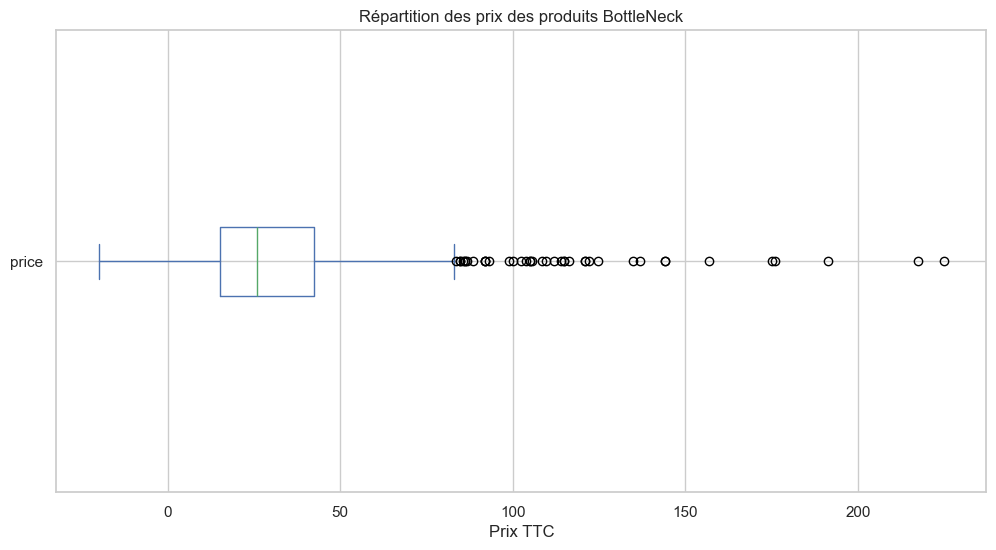

In [59]:
# Boîte à moustaches de la répartition des prix avec Pandas / Matplotlib

ax = df_analyse["price"].plot(kind="box", vert=False, title="Répartition des prix des produits BottleNeck")
ax.set_xlabel("Prix TTC")
plt.show()

In [60]:
# Analyse visuelle des prix extrêmes
# Version statique compatible PyCharm : évite les blocages possibles de Plotly dans certains environnements.

colonnes_prix_extremes = [col for col in ["product_id", "sku", "post_title", "price", "total_sales"] if col in df_analyse.columns]
prix_extremes = df_analyse.sort_values("price", ascending=False)[colonnes_prix_extremes].head(20)

afficher_tableau(prix_extremes, "Top 20 des prix les plus élevés")


,product_id,sku,post_title,price,total_sales
216,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €",11
486,5 001,14581,David Duband Charmes-Chambertin Grand Cru 2014,"217,50 €",2
669,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €",6
235,4 402,3510,Cognac Frapin VIP XO,"176,00 €",3
630,5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €",4
238,4 406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,"157,00 €",4
254,4 594,,Pierre Jean Villa Côte Rôtie Fongeant 2017,"144,00 €",-17
253,4 594,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"144,00 €",-56
435,4 904,14220,Domaine Des Croix Corton Charlemagne Grand Cru 2016,"137,00 €",3
733,6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €",5


,product_id,sku,post_title,price,total_sales
216,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,11.00
486,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,217.50,2.00
669,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,6.00
235,4402,3510,Cognac Frapin VIP XO,176.00,3.00
630,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,4.00
238,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.00,4.00
254,4594,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,144.00,-17.00
253,4594,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,144.00,-56.00
435,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,137.00,3.00
733,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,5.00


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.2 — Identification statistique des valeurs aberrantes
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Application de méthodes statistiques pour repérer les prix atypiques.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.2.1 — Identification par le Z-score
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Un Z-score supérieur à 3 en valeur absolue indique généralement une valeur très éloignée de la moyenne.</p>
</div>

In [61]:
# Calcul de la moyenne, de l'écart-type et du Z-score sur le prix

prix_moyen = df_analyse["price"].mean()
prix_ecart_type = df_analyse["price"].std()

df_analyse["z_score_price"] = (df_analyse["price"] - prix_moyen) / prix_ecart_type

resume_z_score = pd.DataFrame({
    "Indicateur": ["Prix moyen", "Écart-type du prix"],
    "Valeur": [prix_moyen, prix_ecart_type]
})

afficher_tableau(resume_z_score)

Indicateur,Valeur
Prix moyen,"32,51"
Écart-type du prix,"26,43"


,Indicateur,Valeur
0,Prix moyen,32.51
1,Écart-type du prix,26.43


In [62]:
# Articles dont le Z-score du prix est supérieur à 3 en valeur absolue

outliers_zscore_prix = df_analyse[df_analyse["z_score_price"].abs() > 3].copy()
outliers_zscore_prix = outliers_zscore_prix.sort_values("price", ascending=False)

print(f"Nombre d'outliers détectés avec le Z-score : {len(outliers_zscore_prix)}")
afficher_tableau(outliers_zscore_prix[[col for col in ["product_id", "sku", "post_title", "price", "z_score_price"] if col in outliers_zscore_prix.columns]])

Nombre d'outliers détectés avec le Z-score : 19


,product_id,sku,post_title,price,z_score_price
216,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €","7,28 €"
486,5 001,14581,David Duband Charmes-Chambertin Grand Cru 2014,"217,50 €","7,00 €"
669,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €","6,01 €"
235,4 402,3510,Cognac Frapin VIP XO,"176,00 €","5,43 €"
630,5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €","5,39 €"
238,4 406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,"157,00 €","4,71 €"
253,4 594,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"144,00 €","4,22 €"
254,4 594,,Pierre Jean Villa Côte Rôtie Fongeant 2017,"144,00 €","4,22 €"
435,4 904,14220,Domaine Des Croix Corton Charlemagne Grand Cru 2016,"137,00 €","3,95 €"
733,6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €","3,88 €"


,product_id,sku,post_title,price,z_score_price
216,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,7.28
486,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,217.50,7.00
669,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,6.01
235,4402,3510,Cognac Frapin VIP XO,176.00,5.43
630,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,5.39
238,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.00,4.71
253,4594,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,144.00,4.22
254,4594,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,144.00,4.22
435,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,137.00,3.95
733,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,3.88


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        4.2.2 — Identification par l’écart interquartile
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">La méthode IQR isole les valeurs situées au-delà de Q1 - 1,5×IQR ou Q3 + 1,5×IQR.</p>
</div>

In [63]:
# Mesures de dispersion du prix

afficher_tableau(df_analyse[["price"]].describe())

,price
count,"896,00 €"
mean,"32,51 €"
std,"26,43 €"
min,"-20,00 €"
25%,"15,20 €"
50%,"25,80 €"
75%,"42,52 €"
max,"225,00 €"


,price
count,896.00
mean,32.51
std,26.43
min,-20.00
25%,15.20
50%,25.80
75%,42.52
max,225.00


In [64]:
# Calcul des seuils IQR

q1 = df_analyse["price"].quantile(0.25)
q3 = df_analyse["price"].quantile(0.75)
iqr = q3 - q1

seuil_bas_iqr = q1 - 1.5 * iqr
seuil_haut_iqr = q3 + 1.5 * iqr

resume_iqr = pd.DataFrame({
    "Indicateur": ["Q1", "Q3", "IQR", "Seuil bas", "Seuil haut"],
    "Valeur": [q1, q3, iqr, seuil_bas_iqr, seuil_haut_iqr]
})

afficher_tableau(resume_iqr)

Indicateur,Valeur
Q1,"15,20"
Q3,"42,52"
IQR,"27,32"
Seuil bas,"-25,79"
Seuil haut,"83,51"


,Indicateur,Valeur
0,Q1,15.20
1,Q3,42.52
2,IQR,27.32
3,Seuil bas,-25.79
4,Seuil haut,83.51


In [65]:
# Identification des outliers de prix selon l'IQR

outliers_iqr_prix = df_analyse[
    (df_analyse["price"] < seuil_bas_iqr) | (df_analyse["price"] > seuil_haut_iqr)
].copy().sort_values("price", ascending=False)

proportion_outliers_iqr = len(outliers_iqr_prix) / len(df_analyse) * 100 if len(df_analyse) > 0 else 0

print(f"Nombre d'articles outliers selon l'IQR : {len(outliers_iqr_prix)}")
print(f"Proportion du catalogue : {proportion_outliers_iqr:.2f} %")

afficher_tableau(outliers_iqr_prix[[col for col in ["product_id", "sku", "post_title", "price", "total_sales"] if col in outliers_iqr_prix.columns]])

Nombre d'articles outliers selon l'IQR : 40
Proportion du catalogue : 4.46 %


,product_id,sku,post_title,price,total_sales
216,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €",11
486,5 001,14581,David Duband Charmes-Chambertin Grand Cru 2014,"217,50 €",2
669,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €",6
235,4 402,3510,Cognac Frapin VIP XO,"176,00 €",3
630,5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €",4
238,4 406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age,"157,00 €",4
253,4 594,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"144,00 €",-56
254,4 594,,Pierre Jean Villa Côte Rôtie Fongeant 2017,"144,00 €",-17
435,4 904,14220,Domaine Des Croix Corton Charlemagne Grand Cru 2016,"137,00 €",3
733,6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €",5


,product_id,sku,post_title,price,total_sales
216,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,11.00
486,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,217.50,2.00
669,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,6.00
235,4402,3510,Cognac Frapin VIP XO,176.00,3.00
630,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,4.00
238,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.00,4.00
253,4594,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,144.00,-56.00
254,4594,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,144.00,-17.00
435,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,137.00,3.00
733,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,5.00


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Conclusion sur les prix</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Les prix identifiés comme atypiques doivent être analysés avec prudence : dans un catalogue de vins, un prix élevé peut correspondre à un produit premium et ne constitue pas automatiquement une erreur. Ces produits sont donc isolés pour contrôle métier plutôt que supprimés.
    </p>
</div>

<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 5 — Analyses métier
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : analyser le chiffre d’affaires, les quantités vendues, les stocks, les marges et les corrélations.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.1 — Analyse du chiffre d’affaires
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Calcul du chiffre d’affaires par produit et du chiffre d’affaires total du site Web.</p>
</div>

In [66]:
# Calcul du CA par article

df_analyse["ca_par_article"] = df_analyse["price"] * df_analyse["total_sales"]
ca_total = df_analyse["ca_par_article"].sum()

print(f"Chiffre d'affaires total du site Web : {ca_total:,.2f} €")

Chiffre d'affaires total du site Web : -76,889.40 €


In [67]:
# Palmarès des 20 articles générant le plus de CA

top20_ca = df_analyse.sort_values("ca_par_article", ascending=False).head(20).reset_index(drop=True)

afficher_tableau(top20_ca[[col for col in ["product_id", "sku", "post_title", "price", "total_sales", "ca_par_article"] if col in top20_ca.columns]])

product_id,sku,post_title,price,total_sales,ca_par_article
4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"225,00 €",11,"2 475,00 €"
5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"191,30 €",6,"1 147,80 €"
4 233,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"-20,00 €",-56,"1 120,00 €"
4 353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,"79,50 €",14,"1 113,00 €"
5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,"41,20 €",20,"824,00 €"
6 212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,"115,00 €",7,"805,00 €"
5 026,13913,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,"86,80 €",9,"781,20 €"
5 008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,"105,00 €",7,"735,00 €"
5 767,15185,Camille Giroud Clos de Vougeot 2016,"175,00 €",4,"700,00 €"
6 126,14923,Champagne Gosset Célébris Vintage 2007,"135,00 €",5,"675,00 €"


,product_id,sku,post_title,price,total_sales,ca_par_article
0,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00,11.00,"2,475.00"
1,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.30,6.00,"1,147.80"
2,4233,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-20.00,-56.00,"1,120.00"
3,4353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,79.50,14.00,"1,113.00"
4,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,41.20,20.00,824.00
5,6212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santen...,115.00,7.00,805.00
6,5026,13913,Champagne Agrapart &amp; Fils Minéral Extra Br...,86.80,9.00,781.20
7,5008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santen...,105.00,7.00,735.00
8,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00,4.00,700.00
9,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00,5.00,675.00


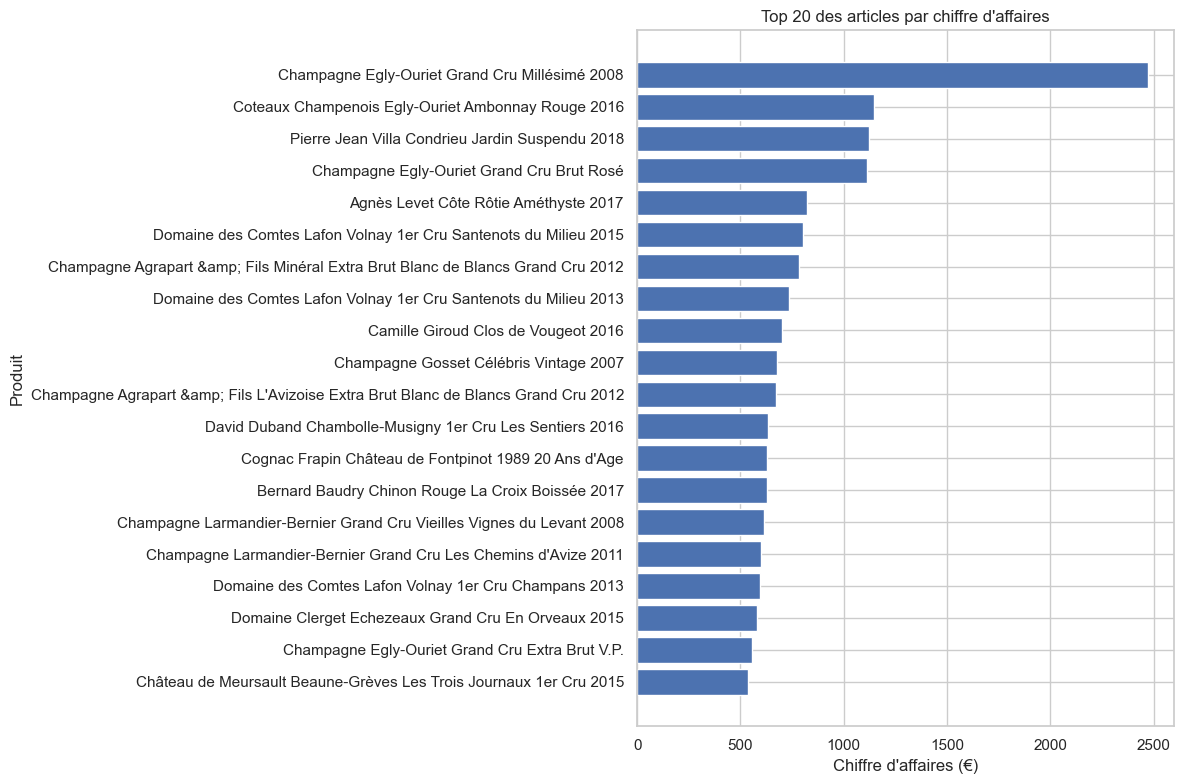

In [68]:
# Graphique en barre des 20 premiers articles en chiffre d'affaires
# Version Matplotlib compatible avec PyCharm et Jupyter, sans dépendre du rendu Plotly.

data_graph = top20_ca.sort_values("ca_par_article")
y_col = "post_title" if "post_title" in data_graph.columns else "product_id"

plt.figure(figsize=(12, 8))
plt.barh(data_graph[y_col].astype(str), data_graph["ca_par_article"])
plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("Produit")
plt.title("Top 20 des articles par chiffre d'affaires")
plt.tight_layout()
plt.show()


In [69]:
# Analyse 20/80 du chiffre d'affaires

df_ca_8020 = df_analyse.sort_values("ca_par_article", ascending=False).copy()
df_ca_8020["part_ca"] = df_ca_8020["ca_par_article"] / df_ca_8020["ca_par_article"].sum()
df_ca_8020["part_ca_cumulee"] = df_ca_8020["part_ca"].cumsum()

produits_80_ca = df_ca_8020[df_ca_8020["part_ca_cumulee"] <= 0.80].copy()
# Ajouter le premier produit qui fait dépasser 80 %, pour être plus juste
if len(produits_80_ca) < len(df_ca_8020):
    produits_80_ca = df_ca_8020.iloc[:len(produits_80_ca) + 1].copy()

nb_produits_80_ca = len(produits_80_ca)
proportion_produits_80_ca = nb_produits_80_ca / len(df_ca_8020) * 100 if len(df_ca_8020) > 0 else 0

print(f"Nombre de produits représentant environ 80 % du CA : {nb_produits_80_ca}")
print(f"Proportion du catalogue : {proportion_produits_80_ca:.2f} %")

afficher_tableau(produits_80_ca[[col for col in ["product_id", "sku", "post_title", "ca_par_article", "part_ca", "part_ca_cumulee"] if col in produits_80_ca.columns]].head(20))

Nombre de produits représentant environ 80 % du CA : 894
Proportion du catalogue : 99.78 %


,product_id,sku,post_title,ca_par_article,part_ca,part_ca_cumulee
216,4 352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"2 475,00 €","-3,22%","-3,22%"
669,5 892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,"1 147,80 €","-1,49%","-4,71%"
156,4 233,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"1 120,00 €","-1,46%","-6,17%"
217,4 353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,"1 113,00 €","-1,45%","-7,62%"
664,5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,"824,00 €","-1,07%","-8,69%"
744,6 212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,"805,00 €","-1,05%","-9,73%"
504,5 026,13913,Champagne Agrapart &amp; Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,"781,20 €","-1,02%","-10,75%"
492,5 008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,"735,00 €","-0,96%","-11,71%"
630,5 767,15185,Camille Giroud Clos de Vougeot 2016,"700,00 €","-0,91%","-12,62%"
733,6 126,14923,Champagne Gosset Célébris Vintage 2007,"675,00 €","-0,88%","-13,49%"


,product_id,sku,post_title,ca_par_article,part_ca,part_ca_cumulee
216,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,"2,475.00",-0.03,-0.03
669,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,"1,147.80",-0.01,-0.05
156,4233,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"1,120.00",-0.01,-0.06
217,4353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,"1,113.00",-0.01,-0.08
664,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,824.00,-0.01,-0.09
744,6212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.00,-0.01,-0.10
504,5026,13913,Champagne Agrapart &amp; Fils Minéral Extra Br...,781.20,-0.01,-0.11
492,5008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santen...,735.00,-0.01,-0.12
630,5767,15185,Camille Giroud Clos de Vougeot 2016,700.00,-0.01,-0.13
733,6126,14923,Champagne Gosset Célébris Vintage 2007,675.00,-0.01,-0.13


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.2 — Analyse des ventes en quantité
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Classement des références selon les quantités vendues et analyse 20/80 en volume.</p>
</div>

In [70]:
# Palmarès des 20 articles les plus vendus en quantité

top20_quantite = df_analyse.sort_values("total_sales", ascending=False).head(20).reset_index(drop=True)

afficher_tableau(top20_quantite[[col for col in ["product_id", "sku", "post_title", "price", "total_sales", "ca_par_article"] if col in top20_quantite.columns]])

product_id,sku,post_title,price,total_sales,ca_par_article
4 867,16148,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,"9,90 €",36,"356,40 €"
4 203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,"9,90 €",27,"267,30 €"
4 275,14864,I Fabbri Chianti Classico Lamole 2017,"14,90 €",24,"357,60 €"
4 726,14950,François Baur Pinot Noir Schlittweg 2017,"12,70 €",22,"279,40 €"
4 647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"28,50 €",22,"627,00 €"
5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,"41,20 €",20,"824,00 €"
6 129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,"5,20 €",20,"104,00 €"
4 220,15758,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,"11,60 €",18,"208,80 €"
5 778,15561,Maurel Pays d'Oc Merlot 2018,"5,80 €",17,"98,60 €"
6 569,15705,Decelle-Villa Chorey-Lès-Beaune 2016,"29,00 €",17,"493,00 €"


,product_id,sku,post_title,price,total_sales,ca_par_article
0,4867,16148,Château De La Selve IGP Coteaux de l'Ardèche M...,9.90,36.00,356.40
1,4203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,9.90,27.00,267.30
2,4275,14864,I Fabbri Chianti Classico Lamole 2017,14.90,24.00,357.60
3,4726,14950,François Baur Pinot Noir Schlittweg 2017,12.70,22.00,279.40
4,4647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,28.50,22.00,627.00
5,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,41.20,20.00,824.00
6,6129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,5.20,20.00,104.00
7,4220,15758,Xavier Frissant Touraine Amboise Chenin Les Pi...,11.60,18.00,208.80
8,5778,15561,Maurel Pays d'Oc Merlot 2018,5.80,17.00,98.60
9,6569,15705,Decelle-Villa Chorey-Lès-Beaune 2016,29.00,17.00,493.00


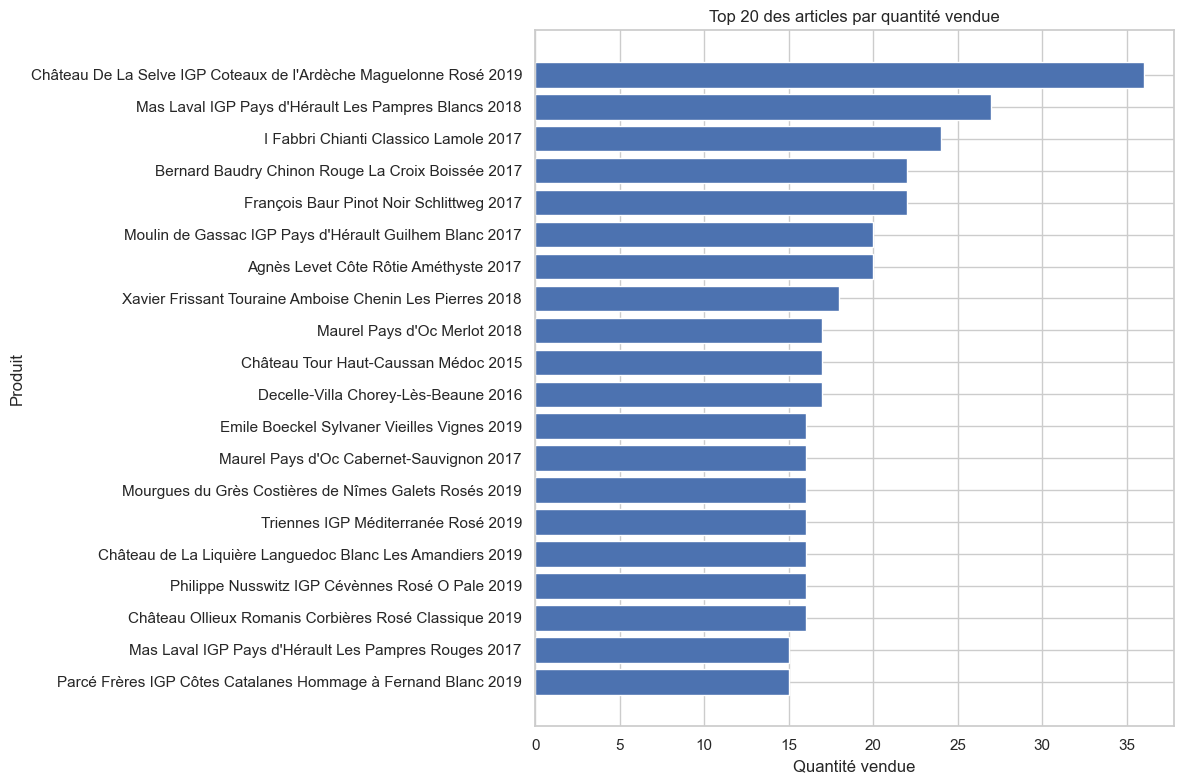

In [71]:
# Graphique en barre des 20 premiers articles en quantité vendue
# Version Matplotlib compatible avec PyCharm et Jupyter.

data_graph = top20_quantite.sort_values("total_sales")
y_col = "post_title" if "post_title" in data_graph.columns else "product_id"

plt.figure(figsize=(12, 8))
plt.barh(data_graph[y_col].astype(str), data_graph["total_sales"])
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")
plt.title("Top 20 des articles par quantité vendue")
plt.tight_layout()
plt.show()


In [72]:
# Analyse 20/80 des ventes en quantité

df_qte_8020 = df_analyse.sort_values("total_sales", ascending=False).copy()
df_qte_8020["part_quantite"] = df_qte_8020["total_sales"] / df_qte_8020["total_sales"].sum()
df_qte_8020["part_quantite_cumulee"] = df_qte_8020["part_quantite"].cumsum()

produits_80_quantite = df_qte_8020[df_qte_8020["part_quantite_cumulee"] <= 0.80].copy()
if len(produits_80_quantite) < len(df_qte_8020):
    produits_80_quantite = df_qte_8020.iloc[:len(produits_80_quantite) + 1].copy()

nb_produits_80_quantite = len(produits_80_quantite)
proportion_produits_80_quantite = nb_produits_80_quantite / len(df_qte_8020) * 100 if len(df_qte_8020) > 0 else 0

print(f"Nombre de produits représentant environ 80 % des quantités vendues : {nb_produits_80_quantite}")
print(f"Proportion du catalogue : {proportion_produits_80_quantite:.2f} %")

afficher_tableau(produits_80_quantite[[col for col in ["product_id", "sku", "post_title", "total_sales", "part_quantite", "part_quantite_cumulee"] if col in produits_80_quantite.columns]].head(20))

Nombre de produits représentant environ 80 % des quantités vendues : 893
Proportion du catalogue : 99.67 %


,product_id,sku,post_title,total_sales,part_quantite,part_quantite_cumulee
416,4 867,16148,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,36,"-4,04%","-4,04%"
130,4 203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,27,"-3,03%","-7,06%"
187,4 275,14864,I Fabbri Chianti Classico Lamole 2017,24,"-2,69%","-9,75%"
364,4 726,14950,François Baur Pinot Noir Schlittweg 2017,22,"-2,47%","-12,22%"
294,4 647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22,"-2,47%","-14,69%"
664,5 826,15325,Agnès Levet Côte Rôtie Améthyste 2017,20,"-2,24%","-16,93%"
736,6 129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,20,"-2,24%","-19,17%"
145,4 220,15758,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,18,"-2,02%","-21,19%"
638,5 778,15561,Maurel Pays d'Oc Merlot 2018,17,"-1,91%","-23,09%"
768,6 569,15705,Decelle-Villa Chorey-Lès-Beaune 2016,17,"-1,91%","-25,00%"


,product_id,sku,post_title,total_sales,part_quantite,part_quantite_cumulee
416,4867,16148,Château De La Selve IGP Coteaux de l'Ardèche M...,36.00,-0.04,-0.04
130,4203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.00,-0.03,-0.07
187,4275,14864,I Fabbri Chianti Classico Lamole 2017,24.00,-0.03,-0.10
364,4726,14950,François Baur Pinot Noir Schlittweg 2017,22.00,-0.02,-0.12
294,4647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.00,-0.02,-0.15
664,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,20.00,-0.02,-0.17
736,6129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.00,-0.02,-0.19
145,4220,15758,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.00,-0.02,-0.21
638,5778,15561,Maurel Pays d'Oc Merlot 2018,17.00,-0.02,-0.23
768,6569,15705,Decelle-Villa Chorey-Lès-Beaune 2016,17.00,-0.02,-0.25


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.3 — Analyse des stocks
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Calcul du nombre de mois de stock, valorisation des stocks et identification des références à surveiller.</p>
</div>

In [73]:
# Calcul du nombre de mois de stock
# Hypothèse : total_sales correspond aux ventes du mois d'octobre.
# mois_stock = stock_quantity / total_sales si total_sales > 0

df_analyse["mois_stock"] = np.where(
    df_analyse["total_sales"] > 0,
    df_analyse["stock_quantity"] / df_analyse["total_sales"],
    np.nan
)

# Produits avec le plus de mois de stock, en excluant les produits sans ventes
flop20_mois_stock = df_analyse[df_analyse["mois_stock"].notna()].sort_values("mois_stock", ascending=False).head(20)

afficher_tableau(flop20_mois_stock[[col for col in ["product_id", "sku", "post_title", "stock_quantity", "total_sales", "mois_stock"] if col in flop20_mois_stock.columns]])

,product_id,sku,post_title,stock_quantity,total_sales,mois_stock
76,4 142,11641,Champagne Gosset Grand Millésime 2006,125,4,31
733,6 126,14923,Champagne Gosset Célébris Vintage 2007,138,5,28
219,4 356,12585,Champagne Egly-Ouriet Premier Cru Les Vignes de Vrigny,81,3,27
214,4 348,12586,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,5,25
80,4 148,1364,Champagne Mailly Grand Cru Brut Rosé,71,3,24
220,4 357,9562,Champagne Larmandier-Bernier Latitude,115,5,23
77,4 144,1662,Champagne Gosset Grand Rosé,91,4,23
503,5 025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,136,6,23
215,4 350,12588,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,7,21
82,4 150,1366,Champagne Mailly Grand Cru Intemporelle 2010,123,6,20


,product_id,sku,post_title,stock_quantity,total_sales,mois_stock
76,4142,11641,Champagne Gosset Grand Millésime 2006,125,4.00,31.25
733,6126,14923,Champagne Gosset Célébris Vintage 2007,138,5.00,27.60
219,4356,12585,Champagne Egly-Ouriet Premier Cru Les Vignes d...,81,3.00,27.00
214,4348,12586,Champagne Egly-Ouriet Grand Cru Brut Tradition,125,5.00,25.00
80,4148,1364,Champagne Mailly Grand Cru Brut Rosé,71,3.00,23.67
220,4357,9562,Champagne Larmandier-Bernier Latitude,115,5.00,23.00
77,4144,1662,Champagne Gosset Grand Rosé,91,4.00,22.75
503,5025,13914,Champagne Agrapart &amp; Fils L'Avizoise Extra...,136,6.00,22.67
215,4350,12588,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,145,7.00,20.71
82,4150,1366,Champagne Mailly Grand Cru Intemporelle 2010,123,6.00,20.50


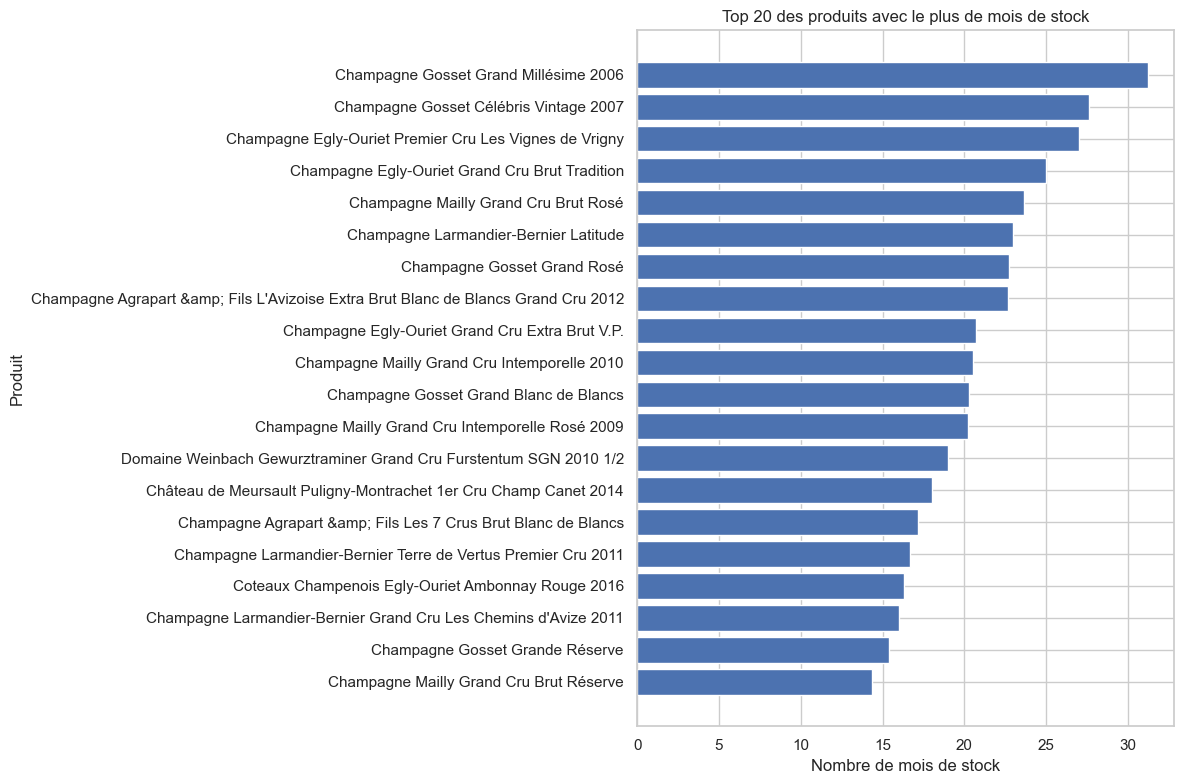

In [74]:
# Graphique des 20 produits avec le plus de mois de stock
# Version Matplotlib compatible avec PyCharm et Jupyter.

data_graph = flop20_mois_stock.sort_values("mois_stock")
y_col = "post_title" if "post_title" in data_graph.columns else "product_id"

plt.figure(figsize=(12, 8))
plt.barh(data_graph[y_col].astype(str), data_graph["mois_stock"])
plt.xlabel("Nombre de mois de stock")
plt.ylabel("Produit")
plt.title("Top 20 des produits avec le plus de mois de stock")
plt.tight_layout()
plt.show()


In [75]:
# Valorisation des stocks en euros
# Valorisation au coût d'achat et valorisation au prix de vente TTC

df_analyse["valorisation_stock_achat"] = df_analyse["stock_quantity"] * df_analyse["purchase_price"]
df_analyse["valorisation_stock_vente_ttc"] = df_analyse["stock_quantity"] * df_analyse["price"]

valorisation_stock_achat_total = df_analyse["valorisation_stock_achat"].sum()
valorisation_stock_vente_total = df_analyse["valorisation_stock_vente_ttc"].sum()
nombre_produits_stock_total = df_analyse["stock_quantity"].sum()

resume_stock = pd.DataFrame({
    "Indicateur": [
        "Nombre total d'unités en stock",
        "Valorisation du stock au prix d'achat",
        "Valorisation du stock au prix de vente TTC"
    ],
    "Valeur": [
        nombre_produits_stock_total,
        valorisation_stock_achat_total,
        valorisation_stock_vente_total
    ]
})

afficher_tableau(resume_stock)

Indicateur,Valeur
Nombre total d'unités en stock,"18 849,00"
Valorisation du stock au prix d'achat,"319 346,11"
Valorisation du stock au prix de vente TTC,"567 754,80"


,Indicateur,Valeur
0,Nombre total d'unités en stock,"18,849.00"
1,Valorisation du stock au prix d'achat,"319,346.11"
2,Valorisation du stock au prix de vente TTC,"567,754.80"


In [76]:
# Produits sans vente mais avec stock disponible : stock dormant potentiel

stock_dormant = df_analyse[(df_analyse["total_sales"] == 0) & (df_analyse["stock_quantity"] > 0)].copy()
stock_dormant = stock_dormant.sort_values("stock_quantity", ascending=False)

print(f"Nombre de produits sans vente mais avec stock disponible : {len(stock_dormant)}")
afficher_tableau(stock_dormant[[col for col in ["product_id", "sku", "post_title", "price", "stock_quantity", "total_sales", "valorisation_stock_achat"] if col in stock_dormant.columns]].head(20))

Nombre de produits sans vente mais avec stock disponible : 3


,product_id,sku,post_title,price,stock_quantity,total_sales,valorisation_stock_achat
213,4 337,4679,Champagne Mailly Grand Cru Les Echansons 2007,"83,00 €",145,0,"7 090,50 €"
218,4 355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,"12,65 €",97,0,"7 515,56 €"
690,5 932,523,Cognac Normandin Mercier VFC,"59,90 €",13,0,"353,34 €"


,product_id,sku,post_title,price,stock_quantity,total_sales,valorisation_stock_achat
213,4337,4679,Champagne Mailly Grand Cru Les Echansons 2007,83.00,145,0.00,"7,090.50"
218,4355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,97,0.00,"7,515.56"
690,5932,523,Cognac Normandin Mercier VFC,59.90,13,0.00,353.34


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.4 — Analyse du taux de marge
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Calcul du prix HT, de la marge unitaire et du taux de marge.</p>
</div>

In [77]:
# Calcul de la marge
# Hypothèse : les prix du fichier ERP sont des prix TTC et la TVA appliquée est de 20 %.

TAUX_TVA = 0.20

df_analyse["prix_ht"] = df_analyse["price"] / (1 + TAUX_TVA)
df_analyse["marge_unitaire"] = df_analyse["prix_ht"] - df_analyse["purchase_price"]
df_analyse["taux_marge"] = np.where(
    df_analyse["purchase_price"] > 0,
    df_analyse["marge_unitaire"] / df_analyse["purchase_price"] * 100,
    np.nan
)
df_analyse["marge_totale"] = df_analyse["marge_unitaire"] * df_analyse["total_sales"]

resume_marge = pd.DataFrame({
    "Indicateur": [
        "Taux de marge minimum",
        "Taux de marge maximum",
        "Taux de marge moyen",
        "Marge totale estimée"
    ],
    "Valeur": [
        df_analyse["taux_marge"].min(),
        df_analyse["taux_marge"].max(),
        df_analyse["taux_marge"].mean(),
        df_analyse["marge_totale"].sum()
    ]
})

afficher_tableau(resume_marge)

Indicateur,Valeur
Taux de marge minimum,"-264,50"
Taux de marge maximum,"91,41"
Taux de marge moyen,"58,63"
Marge totale estimée,"-17 097,84"


,Indicateur,Valeur
0,Taux de marge minimum,-264.50
1,Taux de marge maximum,91.41
2,Taux de marge moyen,58.63
3,Marge totale estimée,"-17,097.84"


In [78]:
# Affichage des produits avec un taux de marge négatif

anomalies_marge_negative = df_analyse[df_analyse["taux_marge"] < 0].copy()

print(f"Nombre de produits avec taux de marge négatif : {len(anomalies_marge_negative)}")
afficher_tableau(anomalies_marge_negative[[col for col in ["product_id", "sku", "post_title", "price", "prix_ht", "purchase_price", "marge_unitaire", "taux_marge"] if col in anomalies_marge_negative.columns]])

Nombre de produits avec taux de marge négatif : 11


,product_id,sku,post_title,price,prix_ht,purchase_price,marge_unitaire,taux_marge
156,4 233,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"-20,00 €","-16,67 €","10,33 €","-27,00 €","-26134,24%"
157,4 233,,Pierre Jean Villa Côte Rôtie Fongeant 2017,"-20,00 €","-16,67 €","10,33 €","-27,00 €","-26134,24%"
218,4 355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,"12,65 €","10,54 €","77,48 €","-66,94 €","-8639,43%"
495,5 017,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"-8,00 €","-6,67 €","4,34 €","-11,01 €","-25360,98%"
496,5 017,,Pierre Jean Villa Côte Rôtie Fongeant 2017,"-8,00 €","-6,67 €","4,34 €","-11,01 €","-25360,98%"
760,6 324,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"92,00 €","76,67 €","99,00 €","-22,33 €","-2255,89%"
761,6 324,,Pierre Jean Villa Côte Rôtie Fongeant 2017,"92,00 €","76,67 €","99,00 €","-22,33 €","-2255,89%"
777,6 594,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"-9,10 €","-7,58 €","4,61 €","-12,19 €","-26449,75%"
778,6 594,,Pierre Jean Villa Côte Rôtie Fongeant 2017,"-9,10 €","-7,58 €","4,61 €","-12,19 €","-26449,75%"
903,7 196,,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"31,00 €","25,83 €","31,20 €","-5,37 €","-1720,09%"


,product_id,sku,post_title,price,prix_ht,purchase_price,marge_unitaire,taux_marge
156,4233,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-20.00,-16.67,10.33,-27.00,-261.34
157,4233,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,-20.00,-16.67,10.33,-27.00,-261.34
218,4355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,10.54,77.48,-66.94,-86.39
495,5017,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-8.00,-6.67,4.34,-11.01,-253.61
496,5017,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,-8.00,-6.67,4.34,-11.01,-253.61
760,6324,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,92.00,76.67,99.00,-22.33,-22.56
761,6324,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,92.00,76.67,99.00,-22.33,-22.56
777,6594,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-9.10,-7.58,4.61,-12.19,-264.50
778,6594,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017,-9.10,-7.58,4.61,-12.19,-264.50
903,7196,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018,31.00,25.83,31.20,-5.37,-17.20


In [79]:
# Analyse des taux de marge positifs

df_marges_positives = df_analyse[df_analyse["taux_marge"] >= 0].copy()

resume_marge_positive = pd.DataFrame({
    "Indicateur": ["Taux de marge positif minimum", "Taux de marge positif maximum", "Taux de marge positif moyen"],
    "Valeur": [
        df_marges_positives["taux_marge"].min(),
        df_marges_positives["taux_marge"].max(),
        df_marges_positives["taux_marge"].mean()
    ]
})

afficher_tableau(resume_marge_positive)

Indicateur,Valeur
Taux de marge positif minimum,"29,50"
Taux de marge positif maximum,"91,41"
Taux de marge positif moyen,"61,31"


,Indicateur,Valeur
0,Taux de marge positif minimum,29.50
1,Taux de marge positif maximum,91.41
2,Taux de marge positif moyen,61.31


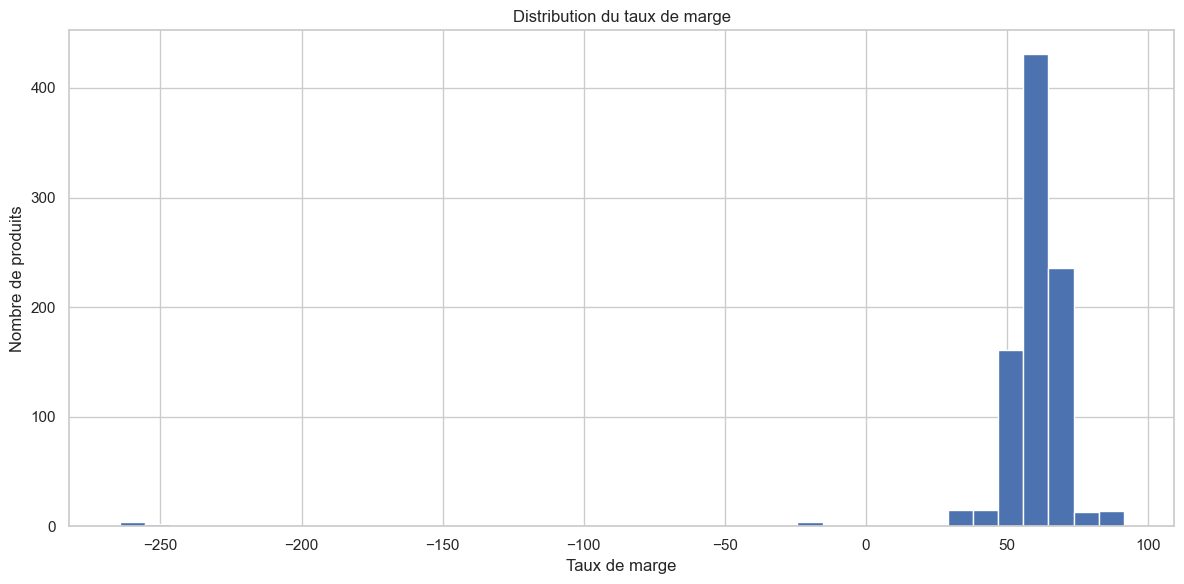

In [80]:
# Graphique de distribution du taux de marge
# Version Matplotlib compatible avec PyCharm et Jupyter.

plt.figure(figsize=(12, 6))
plt.hist(df_analyse["taux_marge"].dropna(), bins=40)
plt.xlabel("Taux de marge")
plt.ylabel("Nombre de produits")
plt.title("Distribution du taux de marge")
plt.tight_layout()
plt.show()


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        5.5 — Analyse des corrélations
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Mesure des relations entre prix, prix d’achat, stock, ventes, CA, prix HT et taux de marge.</p>
</div>

In [81]:
# Matrice de corrélation sur les variables quantitatives principales

variables_correlation = [
    "price", "purchase_price", "prix_ht", "taux_marge", "marge_unitaire",
    "stock_quantity", "total_sales", "ca_par_article", "mois_stock", "valorisation_stock_achat"
]
variables_correlation = [colonne for colonne in variables_correlation if colonne in df_analyse.columns]

matrice_correlation = df_analyse[variables_correlation].corr(numeric_only=True)

afficher_tableau(matrice_correlation)

,price,purchase_price,prix_ht,taux_marge,marge_unitaire,stock_quantity,total_sales,ca_par_article,mois_stock,valorisation_stock_achat
price,"1,00 €","0,96 €","1,00 €","10,88%","0,89 €",-0,-0,"-0,07 €",0,"0,36 €"
purchase_price,"0,96 €","1,00 €","0,96 €","-4,76%","0,73 €",-0,-0,"-0,10 €",0,"0,46 €"
prix_ht,"1,00 €","0,96 €","1,00 €","10,88%","0,89 €",-0,-0,"-0,07 €",0,"0,36 €"
taux_marge,"0,11 €","-0,05 €","0,11 €","100,00%","0,34 €",-0,0,"-0,03 €",-0,"-0,15 €"
marge_unitaire,"0,89 €","0,73 €","0,89 €","34,45%","1,00 €",-0,-0,"-0,02 €",0,"0,14 €"
stock_quantity,"-0,09 €","-0,02 €","-0,09 €","-8,77%","-0,19 €",1,0,"0,18 €",1,"0,71 €"
total_sales,"-0,10 €","-0,12 €","-0,10 €","14,85%","-0,05 €",0,1,"0,83 €",-0,"0,05 €"
ca_par_article,"-0,07 €","-0,10 €","-0,07 €","-2,65%","-0,02 €",0,1,"1,00 €",0,"0,10 €"
mois_stock,"0,21 €","0,26 €","0,21 €","-46,91%","0,11 €",1,-0,"0,14 €",1,"0,78 €"
valorisation_stock_achat,"0,36 €","0,46 €","0,36 €","-14,63%","0,14 €",1,0,"0,10 €",1,"1,00 €"


,price,purchase_price,prix_ht,taux_marge,marge_unitaire,stock_quantity,total_sales,ca_par_article,mois_stock,valorisation_stock_achat
price,1.00,0.96,1.00,0.11,0.89,-0.09,-0.10,-0.07,0.21,0.36
purchase_price,0.96,1.00,0.96,-0.05,0.73,-0.02,-0.12,-0.10,0.26,0.46
prix_ht,1.00,0.96,1.00,0.11,0.89,-0.09,-0.10,-0.07,0.21,0.36
taux_marge,0.11,-0.05,0.11,1.00,0.34,-0.09,0.15,-0.03,-0.47,-0.15
marge_unitaire,0.89,0.73,0.89,0.34,1.00,-0.19,-0.05,-0.02,0.11,0.14
stock_quantity,-0.09,-0.02,-0.09,-0.09,-0.19,1.00,0.27,0.18,0.78,0.71
total_sales,-0.10,-0.12,-0.10,0.15,-0.05,0.27,1.00,0.83,-0.07,0.05
ca_par_article,-0.07,-0.10,-0.07,-0.03,-0.02,0.18,0.83,1.00,0.14,0.10
mois_stock,0.21,0.26,0.21,-0.47,0.11,0.78,-0.07,0.14,1.00,0.78
valorisation_stock_achat,0.36,0.46,0.36,-0.15,0.14,0.71,0.05,0.10,0.78,1.00


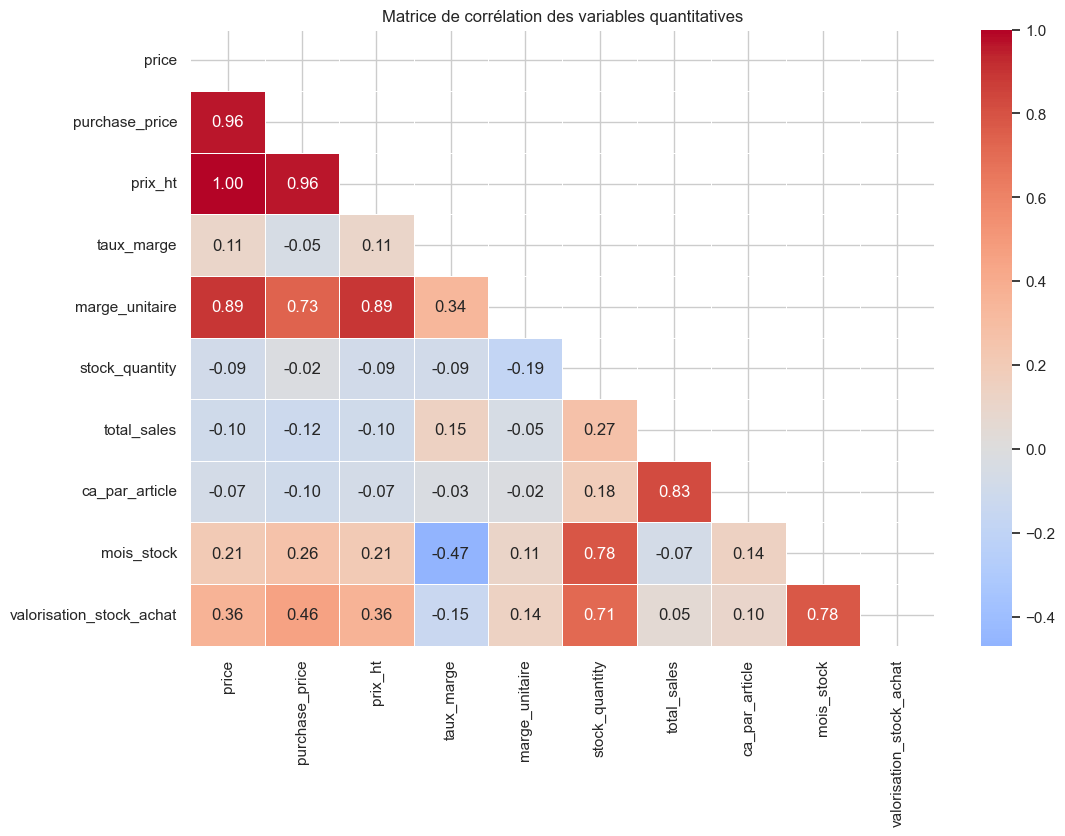

In [82]:
# Heatmap de corrélation

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(matrice_correlation, dtype=bool))
sns.heatmap(
    matrice_correlation,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matrice de corrélation des variables quantitatives")
plt.show()

In [83]:
# Extraction des corrélations les plus fortes en valeur absolue

corr_pairs = (
    matrice_correlation
    .where(~np.eye(matrice_correlation.shape[0], dtype=bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Variable 1", "Variable 2", "Corrélation"]
corr_pairs["Corrélation absolue"] = corr_pairs["Corrélation"].abs()

corr_pairs_fortes = corr_pairs.sort_values("Corrélation absolue", ascending=False).drop_duplicates(
    subset=["Corrélation absolue", "Corrélation"]
).head(15)

afficher_tableau(corr_pairs_fortes)

,Variable 1,Variable 2,Corrélation,Corrélation absolue
2,price,prix_ht,"100,00%","100,00%"
12,purchase_price,prix_ht,"96,05%","96,05%"
10,purchase_price,price,"96,05%","96,05%"
4,price,marge_unitaire,"89,19%","89,19%"
42,marge_unitaire,prix_ht,"89,19%","89,19%"
67,total_sales,ca_par_article,"82,57%","82,57%"
85,mois_stock,stock_quantity,"78,45%","78,45%"
98,valorisation_stock_achat,mois_stock,"77,95%","77,95%"
14,purchase_price,marge_unitaire,"73,09%","73,09%"
59,stock_quantity,valorisation_stock_achat,"71,08%","71,08%"


,Variable 1,Variable 2,Corrélation,Corrélation absolue
2,price,prix_ht,1.00,1.00
12,purchase_price,prix_ht,0.96,0.96
10,purchase_price,price,0.96,0.96
4,price,marge_unitaire,0.89,0.89
42,marge_unitaire,prix_ht,0.89,0.89
67,total_sales,ca_par_article,0.83,0.83
85,mois_stock,stock_quantity,0.78,0.78
98,valorisation_stock_achat,mois_stock,0.78,0.78
14,purchase_price,marge_unitaire,0.73,0.73
59,stock_quantity,valorisation_stock_achat,0.71,0.71


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Conclusion sur les corrélations</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Les corrélations permettent d’identifier les relations statistiques entre variables, mais elles ne prouvent pas une causalité. Les résultats doivent donc être interprétés avec prudence et complétés par une analyse métier.
    </p>
</div>

<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 6 — Journal des anomalies et recommandations
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : centraliser les anomalies détectées et proposer des actions pour améliorer la qualité des données.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        6.1 — Journal des anomalies détectées
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Synthèse des principales anomalies repérées pendant l’exploration, le nettoyage et les jointures.</p>
</div>

In [84]:
# Construction d'un journal des anomalies détectées

journal_anomalies = []

def ajouter_anomalie(source, type_anomalie, description, nb_lignes, action_recommandee):
    journal_anomalies.append({
        "Source": source,
        "Type d'anomalie": type_anomalie,
        "Description": description,
        "Nombre de lignes concernées": int(nb_lignes) if pd.notna(nb_lignes) else 0,
        "Action recommandée": action_recommandee
    })

ajouter_anomalie(
    "ERP",
    "Incohérence métier",
    "Écart entre stock_quantity et stock_status.",
    len(anomalies_stock_status),
    "Corriger le statut de stock à partir d'une règle métier validée."
)

ajouter_anomalie(
    "ERP",
    "Prix manquant, nul ou négatif",
    "Produits dont le prix de vente est absent ou incohérent.",
    len(anomalies_prix_erp),
    "Bloquer la mise en vente si le prix est absent, nul ou négatif."
)

ajouter_anomalie(
    "ERP",
    "Stock négatif",
    "Produits dont le stock est inférieur à zéro.",
    len(anomalies_stock_negatif),
    "Contrôler les mouvements de stock et empêcher les saisies négatives non justifiées."
)

ajouter_anomalie(
    "ERP",
    "Prix d'achat manquant, nul ou négatif",
    "Produits dont le prix d'achat ne permet pas de calculer correctement la marge.",
    len(anomalies_purchase_price),
    "Rendre le prix d'achat obligatoire dans l'ERP."
)

ajouter_anomalie(
    "ERP",
    "Prix d'achat supérieur au prix de vente",
    "Produits potentiellement vendus avec une marge négative avant même le calcul HT.",
    len(anomalies_purchase_superieur_price),
    "Contrôler les prix d'achat et les prix de vente lors de la saisie."
)

ajouter_anomalie(
    "Web",
    "SKU absent",
    "Lignes Web sans code article SKU.",
    len(lignes_sans_sku),
    "Supprimer ou exclure les lignes non produit ; rendre le SKU obligatoire pour les produits."
)

ajouter_anomalie(
    "Web",
    "Format SKU à contrôler",
    "SKU ne respectant pas une codification strictement numérique.",
    len(anomalies_sku_format),
    "Vérifier s'il s'agit de vraies références métier ou d'erreurs de saisie."
)

ajouter_anomalie(
    "Web",
    "SKU en doublon",
    "SKU dupliqués sur les lignes produit du fichier Web.",
    nb_doublons_sku_products,
    "Garantir l'unicité du SKU dans WordPress."
)

ajouter_anomalie(
    "Liaison",
    "Article sans id_web",
    "Produits ERP sans correspondance Web dans la table de liaison.",
    len(articles_sans_id_web),
    "Mettre à jour la table de liaison pour chaque produit vendu sur le Web."
)

ajouter_anomalie(
    "Jointure",
    "ERP sans liaison",
    "Produits ERP non retrouvés dans la table de liaison.",
    len(anomalies_erp_sans_liaison),
    "Automatiser un contrôle de couverture entre ERP et liaison."
)

ajouter_anomalie(
    "Jointure",
    "Liaison sans correspondance Web",
    "Produits avec id_web mais absents des lignes produit Web.",
    len(anomalies_sans_correspondance_web),
    "Contrôler les SKU supprimés, archivés ou mal saisis côté Web."
)

ajouter_anomalie(
    "Prix",
    "Valeur aberrante IQR",
    "Prix identifiés comme atypiques selon la méthode interquartile.",
    len(outliers_iqr_prix),
    "Vérifier s'il s'agit de produits premium ou d'erreurs de saisie."
)

ajouter_anomalie(
    "Marge",
    "Taux de marge négatif",
    "Produits dont le taux de marge calculé est négatif.",
    len(anomalies_marge_negative),
    "Contrôler les prix d'achat, les prix de vente et la règle de TVA."
)

journal_anomalies = pd.DataFrame(journal_anomalies)
afficher_tableau(journal_anomalies)

Source,Type d'anomalie,Description,Nombre de lignes concernées,Action recommandée
ERP,Incohérence métier,Écart entre stock_quantity et stock_status.,2,Corriger le statut de stock à partir d'une règle métier validée.
ERP,"Prix manquant, nul ou négatif",Produits dont le prix de vente est absent ou incohérent.,3,"Bloquer la mise en vente si le prix est absent, nul ou négatif."
ERP,Stock négatif,Produits dont le stock est inférieur à zéro.,2,Contrôler les mouvements de stock et empêcher les saisies négatives non justifiées.
ERP,"Prix d'achat manquant, nul ou négatif",Produits dont le prix d'achat ne permet pas de calculer correctement la marge.,0,Rendre le prix d'achat obligatoire dans l'ERP.
ERP,Prix d'achat supérieur au prix de vente,Produits potentiellement vendus avec une marge négative avant même le calcul HT.,7,Contrôler les prix d'achat et les prix de vente lors de la saisie.
Web,SKU absent,Lignes Web sans code article SKU.,85,Supprimer ou exclure les lignes non produit ; rendre le SKU obligatoire pour les produits.
Web,Format SKU à contrôler,SKU ne respectant pas une codification strictement numérique.,4,Vérifier s'il s'agit de vraies références métier ou d'erreurs de saisie.
Web,SKU en doublon,SKU dupliqués sur les lignes produit du fichier Web.,0,Garantir l'unicité du SKU dans WordPress.
Liaison,Article sans id_web,Produits ERP sans correspondance Web dans la table de liaison.,91,Mettre à jour la table de liaison pour chaque produit vendu sur le Web.
Jointure,ERP sans liaison,Produits ERP non retrouvés dans la table de liaison.,0,Automatiser un contrôle de couverture entre ERP et liaison.


,Source,Type d'anomalie,Description,Nombre de lignes concernées,Action recommandée
0,ERP,Incohérence métier,Écart entre stock_quantity et stock_status.,2,Corriger le statut de stock à partir d'une règ...
1,ERP,"Prix manquant, nul ou négatif",Produits dont le prix de vente est absent ou i...,3,Bloquer la mise en vente si le prix est absent...
2,ERP,Stock négatif,Produits dont le stock est inférieur à zéro.,2,Contrôler les mouvements de stock et empêcher ...
3,ERP,"Prix d'achat manquant, nul ou négatif",Produits dont le prix d'achat ne permet pas de...,0,Rendre le prix d'achat obligatoire dans l'ERP.
4,ERP,Prix d'achat supérieur au prix de vente,Produits potentiellement vendus avec une marge...,7,Contrôler les prix d'achat et les prix de vent...
5,Web,SKU absent,Lignes Web sans code article SKU.,85,Supprimer ou exclure les lignes non produit ; ...
6,Web,Format SKU à contrôler,SKU ne respectant pas une codification stricte...,4,Vérifier s'il s'agit de vraies références méti...
7,Web,SKU en doublon,SKU dupliqués sur les lignes produit du fichie...,0,Garantir l'unicité du SKU dans WordPress.
8,Liaison,Article sans id_web,Produits ERP sans correspondance Web dans la t...,91,Mettre à jour la table de liaison pour chaque ...
9,Jointure,ERP sans liaison,Produits ERP non retrouvés dans la table de li...,0,Automatiser un contrôle de couverture entre ER...


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        6.2 — Recommandations pour améliorer les données dans l’ERP
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Actions concrètes pour fiabiliser les données et réduire les corrections manuelles.</p>
</div>

In [85]:
# Tableau de recommandations pour l'ERP et les processus de données

recommandations_erp = pd.DataFrame({
    "Axe d'amélioration": [
        "Référentiel produit",
        "Clés de jointure",
        "Prix de vente",
        "Prix d'achat",
        "Stock",
        "Statut de stock",
        "Ventes Web",
        "Qualité des données",
        "RGPD"
    ],
    "Recommandation": [
        "Centraliser les informations produit dans un référentiel unique.",
        "Rendre obligatoire une clé commune fiable entre ERP et Web, ou automatiser la table de liaison.",
        "Bloquer les prix manquants, nuls ou négatifs lors de la saisie.",
        "Rendre le prix d'achat obligatoire pour permettre le calcul fiable des marges.",
        "Mettre en place des contrôles sur les stocks négatifs et les stocks dormants.",
        "Calculer automatiquement le statut de stock à partir de la quantité disponible.",
        "Contrôler l'unicité du SKU et exclure les lignes non produit des analyses.",
        "Créer un tableau de bord de suivi des anomalies avec historisation.",
        "Vérifier l'absence de données personnelles et limiter les exports aux données nécessaires."
    ],
    "Impact attendu": [
        "Moins de doublons et de contradictions.",
        "Jointures plus fiables entre ERP et Web.",
        "Réduction des erreurs de chiffre d'affaires.",
        "Marge calculée de manière fiable.",
        "Meilleure gestion de l'approvisionnement.",
        "Moins d'incohérences entre stock et disponibilité.",
        "Analyses de ventes plus propres.",
        "Amélioration continue de la qualité des données.",
        "Réduction du risque réglementaire."
    ]
})

afficher_tableau(recommandations_erp)

Axe d'amélioration,Recommandation,Impact attendu
Référentiel produit,Centraliser les informations produit dans un référentiel unique.,Moins de doublons et de contradictions.
Clés de jointure,"Rendre obligatoire une clé commune fiable entre ERP et Web, ou automatiser la table de liaison.",Jointures plus fiables entre ERP et Web.
Prix de vente,"Bloquer les prix manquants, nuls ou négatifs lors de la saisie.",Réduction des erreurs de chiffre d'affaires.
Prix d'achat,Rendre le prix d'achat obligatoire pour permettre le calcul fiable des marges.,Marge calculée de manière fiable.
Stock,Mettre en place des contrôles sur les stocks négatifs et les stocks dormants.,Meilleure gestion de l'approvisionnement.
Statut de stock,Calculer automatiquement le statut de stock à partir de la quantité disponible.,Moins d'incohérences entre stock et disponibilité.
Ventes Web,Contrôler l'unicité du SKU et exclure les lignes non produit des analyses.,Analyses de ventes plus propres.
Qualité des données,Créer un tableau de bord de suivi des anomalies avec historisation.,Amélioration continue de la qualité des données.
RGPD,Vérifier l'absence de données personnelles et limiter les exports aux données nécessaires.,Réduction du risque réglementaire.


,Axe d'amélioration,Recommandation,Impact attendu
0,Référentiel produit,Centraliser les informations produit dans un r...,Moins de doublons et de contradictions.
1,Clés de jointure,Rendre obligatoire une clé commune fiable entr...,Jointures plus fiables entre ERP et Web.
2,Prix de vente,"Bloquer les prix manquants, nuls ou négatifs l...",Réduction des erreurs de chiffre d'affaires.
3,Prix d'achat,Rendre le prix d'achat obligatoire pour permet...,Marge calculée de manière fiable.
4,Stock,Mettre en place des contrôles sur les stocks n...,Meilleure gestion de l'approvisionnement.
5,Statut de stock,Calculer automatiquement le statut de stock à ...,Moins d'incohérences entre stock et disponibil...
6,Ventes Web,Contrôler l'unicité du SKU et exclure les lign...,Analyses de ventes plus propres.
7,Qualité des données,Créer un tableau de bord de suivi des anomalie...,Amélioration continue de la qualité des données.
8,RGPD,Vérifier l'absence de données personnelles et ...,Réduction du risque réglementaire.


<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        6.3 — Contrôle RGPD
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Vérification rapide de la présence éventuelle de données personnelles dans les fichiers utilisés.</p>
</div>

In [86]:
# Recherche simple de colonnes pouvant contenir des données personnelles

mots_cles_rgpd = [
    "nom", "prenom", "email", "mail", "telephone", "phone", "adresse",
    "address", "client", "user", "ip", "login"
]

colonnes_tous_fichiers = pd.DataFrame({
    "Fichier": ["ERP"] * len(df_erp.columns) + ["Web"] * len(df_web.columns) + ["Liaison"] * len(df_liaison.columns),
    "Colonne": list(df_erp.columns) + list(df_web.columns) + list(df_liaison.columns)
})

colonnes_tous_fichiers["Risque RGPD potentiel"] = colonnes_tous_fichiers["Colonne"].str.lower().apply(
    lambda col: any(mot in col for mot in mots_cles_rgpd)
)

afficher_tableau(colonnes_tous_fichiers[colonnes_tous_fichiers["Risque RGPD potentiel"]])

Fichier,Colonne,Risque RGPD potentiel


,Fichier,Colonne,Risque RGPD potentiel


<div style="
    background-color: #F4FAFB;
    border-left: 6px solid #33A5B6;
    padding: 16px 20px;
    margin: 16px 0 20px 0;
    border-radius: 8px;
">
    <strong style="color:#1E7D8B; font-family:Arial, sans-serif;">Conclusion RGPD</strong>
    <p style="margin: 8px 0 0 0; color:#34495E; font-family:Arial, sans-serif; font-size:14px; line-height:1.6;">
        Les fichiers semblent principalement contenir des données produits, stocks, prix et ventes. Le risque RGPD paraît donc limité, mais une vérification des colonnes et du contenu reste nécessaire avant tout partage externe.
    </p>
</div>

<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Étape 7 — Export de la base consolidée
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Objectif : produire un fichier Excel exploitable contenant la base consolidée et les principaux tableaux de contrôle.</p>
</div>

<div style="
    border-left: 6px solid #33A5B6;
    background-color: #F4FAFB;
    padding: 16px 20px;
    margin: 20px 0 18px 0;
    border-radius: 8px;
">
    <h3 style="
        margin: 0;
        color: #1E7D8B;
        font-family: Arial, sans-serif;
        font-size: 23px;
        font-weight: bold;
    ">
        7.1 — Export Excel
    </h3>
    <p style="margin: 8px 0 0 0; color: #4F6B73; font-family: Arial, sans-serif; font-size: 14px; line-height: 1.5;">Création d’un fichier de sortie avec la base consolidée, la base d’analyse, les anomalies et les recommandations.</p>
</div>

In [87]:
# Export de la base consolidée et des tableaux de contrôle

OUTPUT_DIR = Path("./exports")
OUTPUT_DIR.mkdir(exist_ok=True)

chemin_export = OUTPUT_DIR / "bottleneck_base_consolidee.xlsx"

with pd.ExcelWriter(chemin_export, engine="openpyxl") as writer:
    df_merge.to_excel(writer, sheet_name="base_consolidee", index=False)
    df_analyse.to_excel(writer, sheet_name="base_analyse", index=False)
    journal_anomalies.to_excel(writer, sheet_name="journal_anomalies", index=False)
    recommandations_erp.to_excel(writer, sheet_name="recommandations_erp", index=False)

print(f"Fichier exporté : {chemin_export.resolve()}")

Fichier exporté : C:\Users\steve\Desktop\Openclassrooms2026\P6_Optimisez_la_gestion_&_nettoyez_les_données_du_stock_d_une_boutique\doc_fourni\exports\bottleneck_base_consolidee.xlsx


<div style="
    background: linear-gradient(90deg, #33A5B6, #2C8FA0);
    border-radius: 12px;
    padding: 24px 28px;
    margin: 18px 0 24px 0;
    box-shadow: 0 4px 14px rgba(0,0,0,0.18);
">
    <h2 style="
        margin: 0;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 30px;
        font-weight: bold;
    ">
        Conclusion finale
    </h2>
    <p style="margin: 10px 0 0 0; color: #EAF9FC; font-family: Arial, sans-serif; font-size: 15px; line-height: 1.5;">Synthèse de la préparation, du nettoyage, des analyses et des recommandations.</p>
</div>

### Synthèse

Le travail réalisé dans ce notebook a permis de :

- charger et explorer les trois fichiers sources : ERP, Web et Liaison ;
- contrôler les dimensions, types, valeurs manquantes et doublons ;
- identifier plusieurs familles d’anomalies : incohérences de stock, références non rapprochées, valeurs manquantes, valeurs atypiques, marges négatives potentielles ;
- consolider les données ERP et Web grâce à la table de liaison ;
- calculer les indicateurs métier principaux : chiffre d’affaires, top références, 20/80, stocks, mois de stock, valorisation du stock, marge et corrélations ;
- proposer des recommandations concrètes pour améliorer la fiabilité des données et préparer une future mise en place d’ERP ou de datavisualisation.

### Points de vigilance

Les anomalies détectées ne doivent pas être supprimées automatiquement. Elles doivent être :

1. **isolées** pour ne pas fausser les analyses ;
2. **documentées** pour expliquer leur impact ;
3. **corrigées uniquement lorsqu’une règle métier fiable existe** ;
4. **suivies dans le temps** pour éviter qu’elles ne réapparaissent.

### Prochaine étape

Les résultats du notebook peuvent être utilisés pour construire la présentation au CODIR : méthodologie, anomalies majeures, chiffre d’affaires, stocks, marges, corrélations et recommandations ERP.

## Navigateur web des exports

Cette section génère une page `index.html` unique qui liste tous les exports HTML et affiche chaque tableau dans la page courante (via un iframe), pour une navigation type mini-site web.


In [ ]:
from pathlib import Path
from datetime import datetime

TABLEAUX_DIR = Path("exports/tableaux")
INDEX_PATH = TABLEAUX_DIR / "index.html"

html_files = sorted([p for p in TABLEAUX_DIR.glob("*.html") if p.name != "index.html"])

if not html_files:
    print("Aucun export HTML trouvé dans", TABLEAUX_DIR)
else:
    nav_items = "\n".join(
        f'<li><button onclick="loadPage(\'{p.name}\')">{p.stem.replace("_", " ").title()}</button></li>'
        for p in html_files
    )

    first_page = html_files[0].name

    index_html = f"""<!doctype html>
<html lang="fr">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Exports Bottleneck - Index</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin:0; background:#f5f7fb; }}
    header {{ background:#1f4e79; color:#fff; padding:14px 20px; }}
    .layout {{ display:grid; grid-template-columns: 300px 1fr; min-height: calc(100vh - 58px); }}
    aside {{ background:#fff; border-right:1px solid #e4e9f2; padding:16px; }}
    h2 {{ margin-top:0; font-size:1.05rem; }}
    ul {{ list-style:none; padding:0; margin:0; }}
    li {{ margin:8px 0; }}
    button {{ width:100%; text-align:left; border:1px solid #d3dbe8; background:#f8faff; padding:10px; border-radius:8px; cursor:pointer; }}
    button:hover {{ background:#eef4ff; }}
    main {{ padding:16px; }}
    iframe {{ width:100%; height:calc(100vh - 115px); border:1px solid #d3dbe8; border-radius:8px; background:#fff; }}
    .meta {{ font-size:.85rem; color:#4a5568; margin-top:12px; }}
  </style>
</head>
<body>
  <header><strong>Exports Bottleneck</strong> — Navigation centralisée</header>
  <div class="layout">
    <aside>
      <h2>Tableaux disponibles</h2>
      <ul>{nav_items}</ul>
      <p class="meta">Généré le {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    </aside>
    <main>
      <iframe id="viewer" src="{first_page}" title="Aperçu des exports"></iframe>
    </main>
  </div>
  <script>
    function loadPage(page) {{
      document.getElementById('viewer').src = page;
    }}
  </script>
</body>
</html>
"""

    INDEX_PATH.write_text(index_html, encoding="utf-8")
    print(f"Index généré : {INDEX_PATH.resolve()}")
    print(f"Pages référencées : {len(html_files)}")

